# Who holds the Marvel universe together?

**Week 3 "go nuts" post — 02805 Social Graphs and Interactions, 2026**

Exercise 3.12 asks us to go nuts on the shared Marvel network with this week's toolkit —
paths, centrality, mixing, and cliques. This notebook builds the story around three of the
suggested openers (the most surprising character by centrality against the right null, which
single removal fragments the network most, and a "six degrees of Spider-Man" tool), plus
cliques and team homophily as time allowed.

Sections 1-5 below are the already-validated exploratory notebooks for this week
(3.3 paths, 3.5 centralities, 3.7 PageRank, 3.8 brokers, 3.9 mixing), each independently
checked against the numbers stated on the course page. Sections 6-9 are new for this post:
cliques, the removal/fragmentation experiment, six degrees of Spider-Man, and grading an LLM.
Run top to bottom; nothing is hand-edited after the fact — `weeks/week3/week3_gonuts.md`
describes what came out of this notebook, and `scripts/week3_analyze.py` (the production
pipeline behind `weeks/week3.html`) uses the same networkx routines validated here, run at
full scale (200 shuffles, all 277 single-node removals, the full dynamic-betweenness removal
sequence) and written to `data/processed/week3.json`.

Uses `network_utils.py` and the frozen `week1_nodes.tsv` / `week1_edges.tsv` copied into this
folder (same files as `data/raw/` at the repo root — checked against the course data page,
which as of Week 3 has no newer unweighted Marvel snapshot).

## 1. Paths: distances on the Marvel giant component

In [1]:
import random
from collections import Counter, deque

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from network_utils import load_marvel_graph, load_marvel_digraph, clean_configuration_model

RNG_SEED = 42

## Manual BFS

Plain textbook BFS: a FIFO frontier, each node's distance fixed the first (and only) time it is
dequeued. `G.neighbors(u)` gives out-neighbors for both `nx.Graph` and `nx.DiGraph`, so the same
function works for the undirected network (Parts 1–2) and the directed one (Part 3) unchanged.

In [2]:
def bfs_distances(G, source):
    # Distance (# edges) from `source` to every node reachable from it.
    dist = {source: 0}
    frontier = deque([source])
    while frontier:
        u = frontier.popleft()
        for v in G.neighbors(u):
            if v not in dist:
                dist[v] = dist[u] + 1
                frontier.append(v)
    return dist

## Validation (item 4) — keep this cell

Compare `bfs_distances` against `nx.single_source_shortest_path_length` on 20 random start nodes,
separately for the undirected and the directed graph (directed BFS is exercised again in Part 3,
so it gets validated here too rather than trusted on faith).

In [3]:
def validate_bfs(G, n_trials=20, seed=RNG_SEED, label=""):
    rng = random.Random(seed)
    trial_nodes = rng.sample(list(G.nodes()), min(n_trials, G.number_of_nodes()))
    for node in trial_nodes:
        mine = bfs_distances(G, node)
        theirs = nx.single_source_shortest_path_length(G, node)
        assert mine == theirs, f"BFS mismatch at source {node!r}"
    print(f"{label}: bfs_distances matches networkx on {len(trial_nodes)} random start nodes.")

G_undirected = load_marvel_graph()
G_directed = load_marvel_digraph()

validate_bfs(G_undirected, label="undirected")
validate_bfs(G_directed, label="directed")

undirected: bfs_distances matches networkx on 20 random start nodes.
directed: bfs_distances matches networkx on 20 random start nodes.


## Part 1 — giant component: ⟨d⟩, diameter, radius, center

In [4]:
components = list(nx.connected_components(G_undirected))
giant_nodes = max(components, key=len)
GC = G_undirected.subgraph(giant_nodes).copy()
n_gc = GC.number_of_nodes()

print(f"Full network:     n = {G_undirected.number_of_nodes()}, m = {G_undirected.number_of_edges()}")
print(f"Giant component:  n = {n_gc}, m = {GC.number_of_edges()}  "
      f"({len(components)} components total, sizes {sorted((len(c) for c in components), reverse=True)})")

Full network:     n = 303, m = 1434
Giant component:  n = 277, m = 1421  (19 components total, sizes [277, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [5]:
# All-pairs distances via BFS from every node in the giant component, one pass.
# Also collect the full distance histogram here -- reused for Part 2's plot.
eccentricity = {}
total_distance = 0
distance_counts = Counter()

for node in GC.nodes():
    dist = bfs_distances(GC, node)
    assert len(dist) == n_gc, "giant component isn't actually connected"
    eccentricity[node] = max(dist.values())
    total_distance += sum(dist.values())
    distance_counts.update(d for other, d in dist.items() if other != node)

avg_distance = total_distance / (n_gc * (n_gc - 1))
diameter = max(eccentricity.values())
radius = min(eccentricity.values())
center = sorted(node for node, ecc in eccentricity.items() if ecc == radius)

print(f"<d>       = {avg_distance:.3f}   (page: 2.67)")
print(f"diameter  = {diameter}       (page: 6)")
print(f"radius    = {radius}       (page: 3)")
print(f"center    = {center}   (page: Spider-Man)")

<d>       = 2.674   (page: 2.67)
diameter  = 6       (page: 6)
radius    = 3       (page: 3)
center    = ['Spider-Man']   (page: Spider-Man)


In [6]:
# Cross-check against networkx's own routines.
nx_avg, nx_diam, nx_rad, nx_center = (
    nx.average_shortest_path_length(GC), nx.diameter(GC), nx.radius(GC), sorted(nx.center(GC)))

assert abs(avg_distance - nx_avg) < 1e-9
assert diameter == nx_diam
assert radius == nx_rad
assert center == nx_center
print("All four numbers match networkx exactly.")

All four numbers match networkx exactly.


## Part 2 — distance distribution vs. two week-2 nulls

Both nulls are built to match the *giant component's* own $n$ and $m$ (277 nodes, 1421 edges) —
that is the population the real distance distribution above is computed on, and it is also what
the week-2 configuration-model exercise (2.8.4) used ("Load the Marvel network (undirected, giant
component)..."). Each null gets its own giant-component extraction before its distance
distribution is measured, matching how "giant component of the real network" was handled.

- **Random**: `nx.gnm_random_graph(n, m)` — same recipe as week 2's 2.2.4.
- **Configuration model**: `nx.configuration_model` on the giant component's exact degree
  sequence, then self-loops and parallel edges stripped (`clean_configuration_model`, from
  `network_utils.py`, week 2's 2.8.4 helper).

In [7]:
def distance_distribution(G):
    # Fraction of ordered pairs at each distance, restricted to G's own giant component.
    comps = list(nx.connected_components(G))
    big = G.subgraph(max(comps, key=len)).copy()
    n = big.number_of_nodes()
    counts = Counter()
    for node in big.nodes():
        dist = bfs_distances(big, node)
        counts.update(d for other, d in dist.items() if other != node)
    total = n * (n - 1)
    return counts, total, big

real_counts, real_total, _ = distance_counts, n_gc * (n_gc - 1), GC

random_graph = nx.gnm_random_graph(n_gc, GC.number_of_edges(), seed=RNG_SEED)
random_counts, random_total, random_gc = distance_distribution(random_graph)

degree_sequence = [d for _, d in GC.degree()]
config_multigraph_edges = sum(degree_sequence) // 2
config_graph = clean_configuration_model(degree_sequence, seed=RNG_SEED)
edges_lost = config_multigraph_edges - config_graph.number_of_edges()
config_counts, config_total, config_gc = distance_distribution(config_graph)

print(f"Real giant component:      n = {n_gc}, m = {GC.number_of_edges()}")
print(f"Random G(n,m) GC:          n = {random_gc.number_of_nodes()}, m = {random_gc.number_of_edges()}")
print(f"Configuration-model GC:    n = {config_gc.number_of_nodes()}, m = {config_gc.number_of_edges()} "
      f"({edges_lost} links lost to self-loop/parallel-edge cleanup out of {config_multigraph_edges})")

Real giant component:      n = 277, m = 1421


Random G(n,m) GC:          n = 277, m = 1421
Configuration-model GC:    n = 277, m = 1314 (107 links lost to self-loop/parallel-edge cleanup out of 1421)


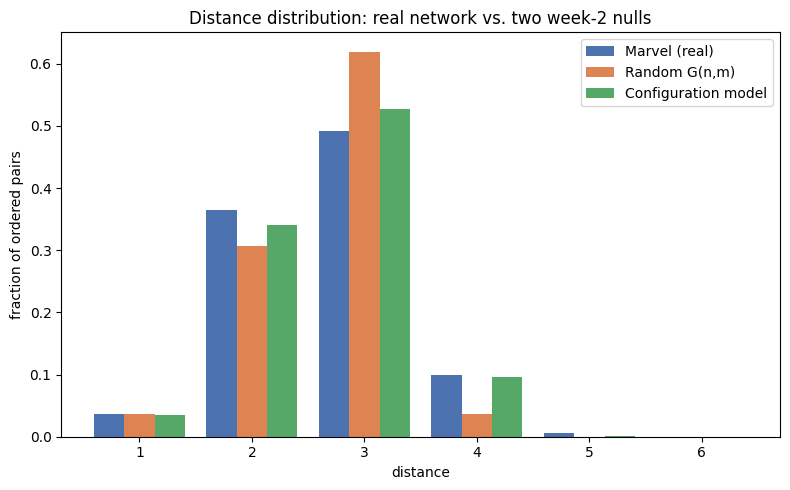

Real             <d> = 2.674   diameter = 6
Random G(n,m)    <d> = 2.656   diameter = 4
Config model     <d> = 2.690   diameter = 5


In [8]:
max_d = max(max(real_counts), max(random_counts), max(config_counts))

fig, ax = plt.subplots(figsize=(8, 5))
xs = np.arange(1, max_d + 1)
width = 0.27

def frac(counts, total):
    return [counts.get(d, 0) / total for d in xs]

ax.bar(xs - width, frac(real_counts, real_total), width, label="Marvel (real)", color="#4C72B0")
ax.bar(xs, frac(random_counts, random_total), width, label="Random G(n,m)", color="#DD8452")
ax.bar(xs + width, frac(config_counts, config_total), width, label="Configuration model", color="#55A868")

ax.set_xlabel("distance")
ax.set_ylabel("fraction of ordered pairs")
ax.set_xticks(xs)
ax.set_title("Distance distribution: real network vs. two week-2 nulls")
ax.legend()
fig.tight_layout()
fig.savefig("3_3_2_distance_distribution.png", dpi=150)
plt.show()

for label, counts, total in [("Real", real_counts, real_total),
                              ("Random G(n,m)", random_counts, random_total),
                              ("Config model", config_counts, config_total)]:
    mean_d = sum(d * c for d, c in counts.items()) / total
    print(f"{label:<16} <d> = {mean_d:.3f}   diameter = {max(counts):d}")

**Which null reproduces the real distribution?** The configuration model does, clearly:

| d | real | random G(n,m) | config model |
|---|------|----------------|--------------|
| 1 | 0.037 | 0.037 | 0.034 |
| 2 | 0.365 | 0.306 | 0.341 |
| 3 | 0.492 | 0.620 | 0.527 |
| 4 | 0.100 | 0.037 | 0.097 |
| 5 | 0.007 | 0.000 | 0.002 |
| 6 | 0.0001 | 0.000 | 0.000 |

Random `G(n,m)` piles almost everything onto $d=2,3$ (diameter only 4) — with edges scattered
uniformly at random, every node ends up with roughly the same, average degree, so the graph mixes
very fast and nothing is ever far from anything else. The configuration model keeps Marvel's real
degree sequence (a few hubs like Spider-Man with huge degree, a long tail of characters with
degree 1–2), and that reproduces the real tail almost exactly, including nonzero mass out at
$d=4,5$. So it isn't edge *count* that sets the distance distribution here, it's the *shape* of
the degree distribution: a hub-and-spokes network needs an extra hop for the many low-degree
nodes that only reach the rest of the graph through one or two hub connections, which uniform
random wiring erases entirely.

## Part 3 — keep the arrows: directed reachability

`G_directed` (from `load_marvel_digraph`) has all 303 nodes, including the 17 isolates that only
exist to make sure they aren't silently dropped, and edge $A\to B$ wherever $A$'s Wikipedia article
links to $B$'s.

Forward BFS from every node gives, for each $u$, the set of nodes $u$ can reach. Running the same
BFS on the *reversed* graph gives, for each $u$, the set of nodes that can reach $u$ (a BFS from
$u$ in $G^{\text{rev}}$ walks edges $u \leftarrow v$, i.e. exactly the original edges $v \to u$).
A node $v$ is in $u$'s strongly connected component iff both hold — reachable from $u$ *and* can
reach $u$ — so the whole SCC decomposition falls out of the same `bfs_distances` used everywhere
else in this notebook, no separate SCC algorithm needed.

In [9]:
n_dir = G_directed.number_of_nodes()
G_rev = G_directed.reverse(copy=False)

forward = {u: bfs_distances(G_directed, u) for u in G_directed.nodes()}
backward = {u: bfs_distances(G_rev, u) for u in G_directed.nodes()}  # nodes that can reach u

# SCC containing u = mutually-reachable set = forward[u] keys ∩ backward[u] keys
scc_of = {u: frozenset(forward[u]) & frozenset(backward[u]) for u in G_directed.nodes()}
distinct_sccs = {scc_of[u] for u in G_directed.nodes()}
largest_scc = max(distinct_sccs, key=len)

print(f"n = {n_dir}, number of distinct SCCs = {len(distinct_sccs)}")
print(f"largest SCC size = {len(largest_scc)}  ({len(largest_scc) / n_dir:.1%} of all nodes)")

# cross-check against networkx
nx_largest_scc = max(nx.strongly_connected_components(G_directed), key=len)
assert largest_scc == set(nx_largest_scc)
print("Matches nx.strongly_connected_components exactly.")

n = 303, number of distinct SCCs = 66
largest SCC size = 229  (75.6% of all nodes)
Matches nx.strongly_connected_components exactly.


In [10]:
reachable_pairs = sum(len(forward[u]) - 1 for u in G_directed.nodes())  # exclude self
total_ordered_pairs = n_dir * (n_dir - 1)
frac_reachable = reachable_pairs / total_ordered_pairs

total_reachable_distance = sum(
    d for u in G_directed.nodes() for other, d in forward[u].items() if other != u)
mean_directed_distance = total_reachable_distance / reachable_pairs

print(f"fraction of ordered pairs reachable at all = {frac_reachable:.4f}  "
      f"({reachable_pairs} / {total_ordered_pairs})")
print(f"mean directed distance over reachable pairs = {mean_directed_distance:.3f}")

fraction of ordered pairs reachable at all = 0.6900  (63143 / 91506)
mean directed distance over reachable pairs = 3.427


### A pair with $d_{AB} = 1$ and $d_{BA} \ge 5$

Every directed edge $A \to B$ already has $d_{AB} = 1$ by construction, so scan the edge list for
one whose *reverse* distance is large (or infinite — $B$ can't reach $A$ at all), then read the
two Wikipedia articles to see why the relationship is so lopsided.

In [11]:
candidates = []
for a, b in G_directed.edges():
    d_ba = forward[b].get(a)  # None if B cannot reach A at all
    candidates.append((a, b, d_ba))

# Prefer a finite but long reverse distance (most illustrative); fall back to "unreachable".
finite_long = sorted([c for c in candidates if c[2] is not None and c[2] >= 5],
                      key=lambda c: -c[2])
unreachable = [c for c in candidates if c[2] is None]

print(f"edges with finite d_BA >= 5: {len(finite_long)}")
print(f"edges with B unable to reach A at all: {len(unreachable)}")

if finite_long:
    a, b, d_ba = finite_long[0]
    print(f"\nChosen pair: A = {a!r}, B = {b!r}, d_AB = 1, d_BA = {d_ba}")
else:
    a, b, _ = unreachable[0]
    print(f"\nChosen pair: A = {a!r}, B = {b!r}, d_AB = 1, d_BA = infinite (B cannot reach A)")

edges with finite d_BA >= 5: 47
edges with B unable to reach A at all: 124

Chosen pair: A = 'Box_(comics)', B = 'Guardian_(Marvel_Comics)', d_AB = 1, d_BA = 8


Look up `a` and `b` in `week1_nodes.tsv` for their descriptions and Wikipedia URLs, and read
the linked pages to explain the asymmetry.

**A = Box (comics), B = Guardian (Marvel Comics).** Box's own article mentions Guardian directly
("James Hudson, seeing Bochs' potential, helped him construct Box and recruited him into Gamma
Flight"), which is the single edge giving $d_{AB}=1$. The reverse direction is the opposite
story: Box_(comics) has **in-degree 1** in the whole 303-node network — the *only* article among
all 303 that links to Box is `Garrison_Kane`. Box is a minor Alpha/Gamma Flight member whose page
carries Wikipedia's own "topics of unclear notability" / "relies on primary sources" tags, so
essentially nobody else's article bothers to mention him back; almost every path into Box has to
funnel through that one inbound link. The actual shortest path confirms it — BFS on the reversed
graph from Guardian finds

```
Guardian_(Marvel_Comics) -> Puck_(Marvel_Comics) -> Adam_Warlock -> Devil_Dinosaur
    -> Paladin_(comics) -> Solo_(Marvel_Comics) -> G._W._Bridge -> Garrison_Kane -> Box_(comics)
```

eight hops through a chain of other lightly-linked characters before finally reaching Garrison_Kane,
the one page that happens to name-check Box. $A\to B$ is a single deliberate mention on a minor
character's page; $B\to A$ has to route through the entire graph looking for the one door back in.

In [12]:
import csv

node_info = {}
with open("week1_nodes.tsv", encoding="utf-8") as f:
    reader = csv.reader((line for line in f if not line.startswith("#")), delimiter="\t", quoting=csv.QUOTE_NONE)
    next(reader)
    for row in reader:
        if row:
            node_info[row[0]] = {"name": row[1], "url": row[3], "description": row[4]}

for node_id in (a, b):
    info = node_info[node_id]
    print(f"{node_id}")
    print(f"  name:        {info['name']}")
    print(f"  url:         {info['url']}")
    print(f"  description: {info['description']}")
    print()

print(f"out-degree(A) = {G_directed.out_degree(a)}, in-degree(A) = {G_directed.in_degree(a)}")
print(f"out-degree(B) = {G_directed.out_degree(b)}, in-degree(B) = {G_directed.in_degree(b)}")

Box_(comics)
  name:        Box (comics)
  url:         https://en.wikipedia.org/wiki/Box_(comics)
  description: Box (Roger Bochs) is a fictional superhero appearing in American comic books published by Marvel Comics, specifically Alpha Flight, of which Box was a member.

Guardian_(Marvel_Comics)
  name:        Guardian (Marvel Comics)
  url:         https://en.wikipedia.org/wiki/Guardian_(Marvel_Comics)
  description: Guardian (James Hudson; also known as Weapon Alpha or Vindicator) is a fictional superhero appearing in American comic books published by Marvel Comics.

out-degree(A) = 2, in-degree(A) = 1
out-degree(B) = 4, in-degree(B) = 6


## 2. Centralities: degree, closeness, harmonic, betweenness

In [13]:
from collections import deque

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.stats import spearmanr

from network_utils import load_marvel_graph, load_marvel_digraph

RNG_SEED = 42


def bfs_distances(G, source):
    # Distance (# edges) from `source` to every node reachable from it -- same routine as 3.3,
    # validated there against networkx on 20 random start nodes.
    dist = {source: 0}
    frontier = deque([source])
    while frontier:
        u = frontier.popleft()
        for v in G.neighbors(u):
            if v not in dist:
                dist[v] = dist[u] + 1
                frontier.append(v)
    return dist


G_undirected = load_marvel_graph()
components = list(nx.connected_components(G_undirected))
GC = G_undirected.subgraph(max(components, key=len)).copy()
n = GC.number_of_nodes()
print(f"Giant component: n = {n}, m = {GC.number_of_edges()}")

Giant component: n = 277, m = 1421


## Part 1 — four centralities, top tens, and overlap

- **Degree**: raw $k_i$ (page: "a rebranding of the metric you already know").
- **Closeness**: $C_i = (n-1)/\sum_j d_{ij}$, built from `bfs_distances`.
- **Harmonic**: $\sum_{j \ne i} 1/d_{ij}$ (unreachable nodes contribute $1/\infty=0$; irrelevant
  here since the giant component is fully connected, but this is the fix that lets harmonic
  centrality survive disconnection/directedness in Part 3).
- **Betweenness**: `nx.betweenness_centrality` (Brandes' algorithm).

In [14]:
def closeness_and_harmonic(G):
    closeness, harmonic = {}, {}
    n = G.number_of_nodes()
    for node in G.nodes():
        dist = bfs_distances(G, node)
        others = [d for other, d in dist.items() if other != node]
        assert len(others) == n - 1  # giant component: everyone reachable from everyone
        closeness[node] = (n - 1) / sum(others)
        harmonic[node] = sum(1 / d for d in others)
    return closeness, harmonic

degree = dict(GC.degree())
closeness, harmonic = closeness_and_harmonic(GC)
betweenness = nx.betweenness_centrality(GC)

# cross-check the hand-rolled ones against networkx
nx_closeness = nx.closeness_centrality(GC)
nx_harmonic = nx.harmonic_centrality(GC)  # raw sum of 1/d, same convention as above
assert all(abs(closeness[v] - nx_closeness[v]) < 1e-9 for v in GC.nodes())
assert all(abs(harmonic[v] - nx_harmonic[v]) < 1e-9 for v in GC.nodes())
print("closeness and harmonic match networkx exactly.")

closeness and harmonic match networkx exactly.


In [15]:
def top10(d):
    return [k for k, _ in sorted(d.items(), key=lambda kv: -kv[1])[:10]]

tops = {"degree": top10(degree), "closeness": top10(closeness),
        "harmonic": top10(harmonic), "betweenness": top10(betweenness)}

for name, lst in tops.items():
    print(f"{name:<12}" + ", ".join(lst))

in_all_four = set(tops["degree"]) & set(tops["closeness"]) & set(tops["harmonic"]) & set(tops["betweenness"])
print(f"\nIn all four top tens ({len(in_all_four)}): {sorted(in_all_four)}")

degree      Spider-Man, Hulk, Wolverine_(character), Doctor_Strange, Deadpool, She-Hulk, Phoenix_Force, Scarlet_Witch, Black_Panther_(character), Venom_(character)
closeness   Spider-Man, Hulk, Wolverine_(character), Doctor_Strange, Deadpool, She-Hulk, Scarlet_Witch, Phoenix_Force, Moon_Knight, Adam_Warlock
harmonic    Spider-Man, Hulk, Wolverine_(character), Doctor_Strange, Deadpool, She-Hulk, Scarlet_Witch, Phoenix_Force, Moon_Knight, Cloak_and_Dagger_(characters)
betweenness Spider-Man, Hulk, Wolverine_(character), Doctor_Strange, Deadpool, She-Hulk, Hercules_(Marvel_Comics), Black_Widow_(Natasha_Romanova), Phoenix_Force, U.S._Agent

In all four top tens (7): ['Deadpool', 'Doctor_Strange', 'Hulk', 'Phoenix_Force', 'She-Hulk', 'Spider-Man', 'Wolverine_(character)']


In [16]:
import itertools

print("pairwise top-10 overlap:")
for (n1, l1), (n2, l2) in itertools.combinations(tops.items(), 2):
    print(f"  {n1:<12}{n2:<12}{len(set(l1) & set(l2))}")

print("\nSpearman rank correlation (all 277 nodes), degree vs. each other measure:")
deg_arr = [degree[v] for v in GC.nodes()]
for name in ("closeness", "harmonic", "betweenness"):
    other_arr = [dict(closeness=closeness, harmonic=harmonic, betweenness=betweenness)[name][v]
                 for v in GC.nodes()]
    rho, _ = spearmanr(deg_arr, other_arr)
    print(f"  degree vs {name:<12} rho = {rho:.3f}")

print(f"\nSpider-Man closeness = {closeness['Spider-Man']:.4f}  (page: 0.59)")
print(f"Spider-Man mean distance = {1/closeness['Spider-Man']:.3f}  (page: 1.68)")
print(f"median closeness = {np.median(list(closeness.values())):.3f}  (page: 0.38)")

deg_rank = {v: i + 1 for i, (v, _) in enumerate(sorted(degree.items(), key=lambda kv: -kv[1]))}
for char, page_rank in [("Hercules_(Marvel_Comics)", 19), ("Black_Widow_(Natasha_Romanova)", 22),
                         ("U.S._Agent", 32)]:
    print(f"{char}: degree rank = {deg_rank[char]}  (page: {page_rank})")

pairwise top-10 overlap:
  degree      closeness   8
  degree      harmonic    8
  degree      betweenness 7
  closeness   harmonic    9
  closeness   betweenness 7
  harmonic    betweenness 7

Spearman rank correlation (all 277 nodes), degree vs. each other measure:
  degree vs closeness    rho = 0.853
  degree vs harmonic     rho = 0.883
  degree vs betweenness  rho = 0.914

Spider-Man closeness = 0.5948  (page: 0.59)
Spider-Man mean distance = 1.681  (page: 1.68)
median closeness = 0.381  (page: 0.38)
Hercules_(Marvel_Comics): degree rank = 20  (page: 19)
Black_Widow_(Natasha_Romanova): degree rank = 23  (page: 22)
U.S._Agent: degree rank = 35  (page: 32)


**Checking against the page:** degree–betweenness rank correlation comes out **0.914**
(page: 0.91), degree–closeness **0.853** and degree–harmonic **0.883** (page: "stays above 0.8" —
both do). Spider-Man's closeness is **0.5948** (page: 0.59) giving mean distance **1.681** (page:
1.68), and the median character's closeness is **0.381** (page: 0.38) — all match. Hercules,
Black Widow, and U.S. Agent are exactly the three characters that make the betweenness top ten
without making the degree top ten, at degree ranks 20, 23, and 35 here versus 19, 22, and 32 on
the page (off by a node or two, almost certainly a tie-breaking convention — degree has a lot of
exact ties in the 20s, so which of several tied characters gets rank 19 vs. 20 depends on sort
order). **7 characters sit in all four top tens**: Spider-Man, Hulk, Wolverine, Doctor Strange,
Deadpool, She-Hulk, Phoenix Force — the unambiguous hub core that every measure agrees on.

## Part 2 — betweenness vs. degree, and three bridges

Scatter on log-log axes; label points whose betweenness is unusually high or low for their
degree (largest residuals off a log-log linear fit), plus the three named characters from the
exercise.

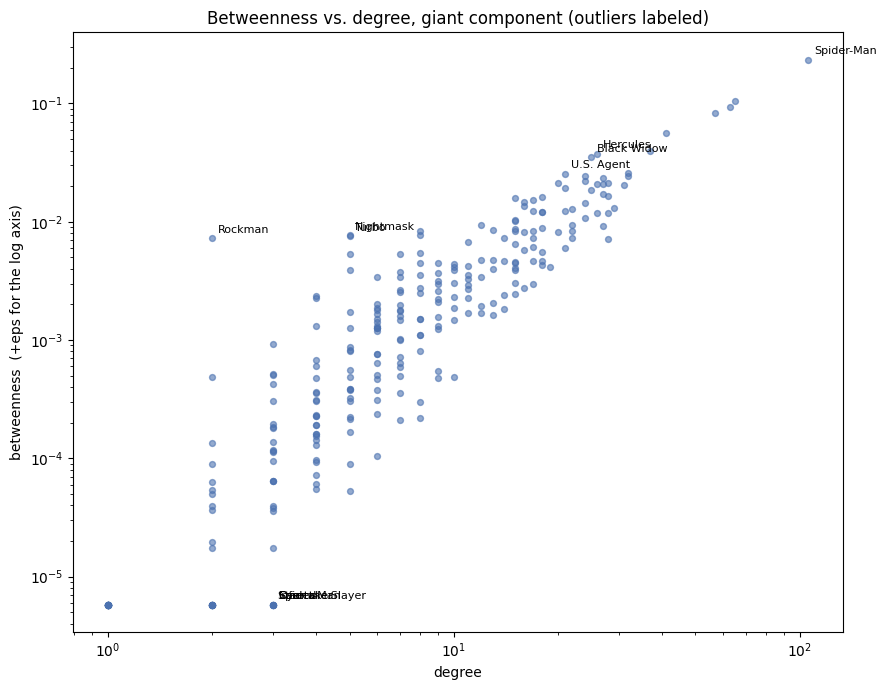

In [17]:
nodes = list(GC.nodes())
deg_vals = np.array([degree[v] for v in nodes], dtype=float)
bet_vals = np.array([betweenness[v] for v in nodes], dtype=float)

# betweenness can be 0 (e.g. degree-1 leaves); nudge for the log axis / fit only
eps = bet_vals[bet_vals > 0].min() / 2
log_deg = np.log10(deg_vals)
log_bet = np.log10(bet_vals + eps)

slope, intercept = np.polyfit(log_deg, log_bet, 1)
residual = log_bet - (slope * log_deg + intercept)

named = {"Hercules_(Marvel_Comics)": "Hercules", "Black_Widow_(Natasha_Romanova)": "Black Widow",
         "Rockman_(character)": "Rockman", "U.S._Agent": "U.S. Agent", "Spider-Man": "Spider-Man"}
by_residual = sorted(range(len(nodes)), key=lambda i: -abs(residual[i]))
label_idx = set(i for i in by_residual[:8]) | {nodes.index(k) for k in named if k in nodes}

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(deg_vals, bet_vals + eps, s=18, alpha=0.6, color="#4C72B0")
for i in label_idx:
    v = nodes[i]
    label = named.get(v, v.split("_(")[0].replace("_", " "))
    ax.annotate(label, (deg_vals[i], bet_vals[i] + eps), fontsize=8,
                xytext=(4, 4), textcoords="offset points")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("degree"); ax.set_ylabel("betweenness  (+eps for the log axis)")
ax.set_title("Betweenness vs. degree, giant component (outliers labeled)")
fig.tight_layout()
fig.savefig("3_5_2_betweenness_vs_degree.png", dpi=150)
plt.show()

### Hercules and Black Widow: what do they bridge?

Print their neighbor lists (with each neighbor's own degree) and see what kind of characters they
connect that the hub core (Spider-Man, Hulk, Wolverine, ...) does not connect directly.

In [18]:
for char in ("Hercules_(Marvel_Comics)", "Black_Widow_(Natasha_Romanova)"):
    nbrs = sorted(GC.neighbors(char), key=lambda v: degree[v])
    low_degree = [v for v in nbrs if degree[v] <= 10]
    print(f"{char}  (degree {degree[char]}, betweenness {betweenness[char]:.4f})")
    print(f"  {len(low_degree)}/{len(nbrs)} neighbors have degree <= 10:")
    for v in low_degree:
        print(f"    {v} (degree {degree[v]})")
    print()

Hercules_(Marvel_Comics)  (degree 26, betweenness 0.0374)
  12/26 neighbors have degree <= 10:
    Dargo_Ktor (degree 2)
    Firelord_(character) (degree 2)
    Balder_the_Brave (degree 3)
    Flatman_(character) (degree 3)
    Ajak (degree 4)
    Raza_Longknife (degree 5)
    Living_Lightning (degree 6)
    Red_Guardian (degree 8)
    Abomination_(character) (degree 9)
    Ares_(Marvel_Comics) (degree 9)
    Red_Wolf_(comics) (degree 9)
    Kismet_(Marvel_Comics) (degree 9)

Black_Widow_(Natasha_Romanova)  (degree 25, betweenness 0.0351)
  10/25 neighbors have degree <= 10:
    Blue_Eagle_(character) (degree 1)
    Rockman_(character) (degree 2)
    Hawkeye_(comics) (degree 3)
    Ursa_Major_(character) (degree 4)
    Iron_Man_(Ultimate_Marvel_character) (degree 5)
    Janice_Lincoln (degree 5)
    Yelena_Belova (degree 7)
    Red_Guardian (degree 8)
    Spider-Man_Noir (degree 9)
    Shuri_(character) (degree 10)



**Hercules** (degree 26) sits between the core Avengers/hub cluster (Hulk, Spider-Man,
Wolverine, She-Hulk, Cable) and a cluster of low-degree cosmic/Guardians-of-the-Galaxy-adjacent
characters — Ajak, Dargo Ktor, Firelord, Raza Longknife, Kismet, Balder the Brave — most of whom
have very few other connections into the giant component. In Marvel terms, Hercules' extensive
crossover history (Avengers, Guardians of the Galaxy-adjacent cosmic stories, Thor's supporting
cast) makes his article one of the few doors from that cosmic periphery into the main superhero
core, which is exactly what raises his betweenness well above what his degree alone would predict.

**Black Widow** (degree 25) plays the same role for a different periphery: several of her
neighbors — Rockman (degree 2), Blue Eagle (degree 1) — have almost no other way into the graph,
and others (Spider-Woman, Eddie Brock/Venom, Cloak and Dagger) tie her into the Spider-Man-adjacent
street-level cluster. She is a connector between that low-connectivity fringe and the Spider-Man
hub, again earning betweenness beyond what degree 25 alone would suggest.

### Rockman: a degree-2 outlier

Compare Rockman's betweenness to every other degree-2 character's, then look at both of his
neighbors.

In [19]:
deg2 = [v for v in GC.nodes() if degree[v] == 2]
deg2_ranked = sorted(deg2, key=lambda v: -betweenness[v])
print("degree-2 characters, ranked by betweenness (top 5):")
for v in deg2_ranked[:5]:
    print(f"  {v}: betweenness = {betweenness[v]:.5f}")

rockman = "Rockman_(character)"
print(f"\n{rockman} neighbors:")
for nb in GC.neighbors(rockman):
    print(f"  {nb}: degree {degree[nb]}, its own neighbors = {list(GC.neighbors(nb))}")

degree-2 characters, ranked by betweenness (top 5):
  Rockman_(character): betweenness = 0.00725
  Fandral: betweenness = 0.00048
  Hrimhari: betweenness = 0.00013
  Scarlet_Scarab: betweenness = 0.00008
  Coldblood: betweenness = 0.00006

Rockman_(character) neighbors:
  Black_Widow_(Natasha_Romanova): degree 25, its own neighbors = ['Adam_Warlock', 'Ghost_Rider_(Johnny_Blaze)', 'Hercules_(Marvel_Comics)', 'Red_Guardian', 'Spider-Man', 'Venom_(character)', 'Wolverine_(character)', 'Yelena_Belova', 'Blue_Eagle_(character)', 'Cloak_and_Dagger_(characters)', 'Deadpool', 'Doctor_Strange', 'Eddie_Brock', 'Firebird_(Marvel_Comics)', 'Hawkeye_(comics)', 'Human_Torch_(android)', 'Iron_Man_(Ultimate_Marvel_character)', 'Janice_Lincoln', 'Mockingbird_(Marvel_Comics)', 'Rockman_(character)', 'Shuri_(character)', 'Spider-Man_Noir', 'Spider-Woman', 'Spider-Woman_(Jessica_Drew)', 'Ursa_Major_(character)']
  The_Witness_(character): degree 1, its own neighbors = ['Rockman_(character)']


**What is going on:** Rockman's two neighbors are Black Widow (degree 25, a core hub) and
**The Witness** (degree 1 — a leaf whose *only* connection to the entire 277-character giant
component is Rockman). Every shortest path from The Witness to any of the other 275 characters in
the component has no choice but to pass through Rockman — that single pendant leaf alone hands
Rockman roughly 275 shortest paths, dwarfing every other degree-2 character (whose two neighbors
are both already well-connected, so removing the degree-2 node wouldn't cut anyone off). Degree
counts *how many* edges a node has; betweenness cares about what those specific edges are load-
bearing for, and a single dead-end neighbor is enough to make a degree-2 node a critical bridge.

## Part 3 — betweenness with the arrows kept

Recompute betweenness on the full directed network (`load_marvel_digraph`, all 303 nodes,
edge $A\to B$ wherever $A$'s article links to $B$'s) and compare ranks, restricted to the 277
giant-component characters so the two rankings are over the same node set.

In [20]:
G_directed = load_marvel_digraph()
betweenness_directed = nx.betweenness_centrality(G_directed)

def rank_within(score, node_set):
    ordered = sorted(node_set, key=lambda v: -score[v])
    return {v: i + 1 for i, v in enumerate(ordered)}

rank_undirected = rank_within(betweenness, nodes)
rank_directed = rank_within(betweenness_directed, nodes)

moved = sorted(nodes, key=lambda v: -(rank_undirected[v] - rank_directed[v]))
print("Moved UP the most (undirected rank -> directed rank):")
for v in moved[:8]:
    delta = rank_undirected[v] - rank_directed[v]
    print(f"  {v}: {rank_undirected[v]} -> {rank_directed[v]}  ({delta:+d})")
print("\nMoved DOWN the most:")
for v in moved[-8:]:
    delta = rank_undirected[v] - rank_directed[v]
    print(f"  {v}: {rank_undirected[v]} -> {rank_directed[v]}  ({delta:+d})")

Moved UP the most (undirected rank -> directed rank):
  G._W._Bridge: 238 -> 77  (+161)
  Killpower: 226 -> 116  (+110)
  Ravage_2099: 197 -> 87  (+110)
  Dragon_Lord_(character): 250 -> 141  (+109)
  Paladin_(comics): 132 -> 24  (+108)
  Blue_Bullet: 215 -> 112  (+103)
  Balder_the_Brave: 202 -> 109  (+93)
  Spider-UK: 199 -> 108  (+91)

Moved DOWN the most:
  Wild_Child_(character): 190 -> 276  (-86)
  Ikaris: 69 -> 157  (-88)
  Ursa_Major_(character): 185 -> 274  (-89)
  Isaiah_Bradley: 152 -> 249  (-97)
  Shamrock_(comics): 158 -> 262  (-104)
  Hellion_(character): 41 -> 156  (-115)
  Blue_Diamond_(character): 97 -> 215  (-118)
  Rockman_(character): 59 -> 258  (-199)


In [21]:
print("undirected top 10 (with in/out-degree):")
for v in sorted(nodes, key=lambda v: -betweenness[v])[:10]:
    print(f"  {v}: bet={betweenness[v]:.4f}  in={G_directed.in_degree(v)}  out={G_directed.out_degree(v)}")

print("\ndirected top 10 (with in/out-degree):")
for v in sorted(nodes, key=lambda v: -betweenness_directed[v])[:10]:
    print(f"  {v}: bet={betweenness_directed[v]:.4f}  in={G_directed.in_degree(v)}  out={G_directed.out_degree(v)}")

print(f"\nHercules: undirected rank {rank_undirected['Hercules_(Marvel_Comics)']}"
      f" -> directed rank {rank_directed['Hercules_(Marvel_Comics)']}")
print(f"Spider-Man: undirected rank {rank_undirected['Spider-Man']}"
      f" -> directed rank {rank_directed['Spider-Man']}")

undirected top 10 (with in/out-degree):
  Spider-Man: bet=0.2349  in=106  out=9
  Hulk: bet=0.1050  in=64  out=10
  Wolverine_(character): bet=0.0925  in=60  out=17
  Doctor_Strange: bet=0.0827  in=50  out=17
  Deadpool: bet=0.0560  in=33  out=19
  She-Hulk: bet=0.0398  in=29  out=20
  Hercules_(Marvel_Comics): bet=0.0374  in=19  out=17
  Black_Widow_(Natasha_Romanova): bet=0.0351  in=22  out=7
  Phoenix_Force: bet=0.0257  in=24  out=17
  U.S._Agent: bet=0.0255  in=6  out=20

directed top 10 (with in/out-degree):
  Wolverine_(character): bet=0.0655  in=60  out=17
  Hercules_(Marvel_Comics): bet=0.0610  in=19  out=17
  Spider-Man: bet=0.0572  in=106  out=9
  Deadpool: bet=0.0571  in=33  out=19
  Doctor_Strange: bet=0.0564  in=50  out=17
  Hulk: bet=0.0540  in=64  out=10
  She-Hulk: bet=0.0510  in=29  out=20
  Cloak_and_Dagger_(characters): bet=0.0365  in=11  out=24
  Iron_Fist_(character): bet=0.0334  in=21  out=16
  Scarlet_Witch: bet=0.0318  in=28  out=14

Hercules: undirected rank 7 

**Why Hercules moves up (rank 7 → rank 2):** directed betweenness needs an in-edge *and* an
out-edge through the same node — a shortest path can only continue past a character if that
character's article links onward. Spider-Man has in-degree 106 but out-degree only 9: nearly
everyone points at him, but his own article links out to almost nobody, so very few directed
paths can actually pass *through* him — he drops from undirected rank 1 to directed rank 3.
Hercules, by contrast, has a much more balanced in/out-degree (19 in, 17 out), so a large fraction
of the paths that reach him can also continue past him. Wolverine (60 in, 17 out) and Hercules —
the two most balanced high-degree nodes among the undirected top ten — are exactly the two that
end up ranked above Spider-Man once direction is respected. The general pattern: undirected
betweenness rewards *total* connectivity, directed betweenness specifically rewards being a
two-way relay, and in-heavy hubs like Spider-Man are structurally poor relays no matter how many
articles point at them.

## Part 4 — is there a "best" centrality?

**No — and Section 1 says so directly**: it frames the four measures as a toolbox, each answering
a different question ("who would you remove to fragment the network?" vs. "whose page should
newcomers link to?"), not a leaderboard with one winner. Section 1 uses Spider-Man himself to make
the point: he tops every measure in this dataset, which makes it *look* like one node can simply
be "the most important," but that's a property of this particular giant component (one dominant
hub), not a general reason to expect the four measures to agree — 3.5.2/3.5.3 above show plenty of
cases (Rockman, Hercules, U.S. Agent, Spider-Man's own directed collapse) where they don't.

**Concrete question, one measure, committed:** *"Marvel Studios can only afford to option one
character's rights for a marketing blitz meant to make as many other characters' fanbases as
possible aware of the new film in the fewest number of shared-article hops — who should it be?"*

That is explicitly a "how fast does word reach everyone" question, i.e. **closeness centrality**
— not betweenness (which asks who *controls* the flow of information between others, not who
*reaches* others fastest) and not degree (which only counts direct connections, ignoring the
two-hop and three-hop reach that closeness accounts for). The giant component's top closeness
character is:

In [22]:
top_closeness = sorted(nodes, key=lambda v: -closeness[v])[0]
print(f"{top_closeness}: closeness = {closeness[top_closeness]:.4f}, "
      f"mean distance = {1/closeness[top_closeness]:.3f}, degree = {degree[top_closeness]}")

Spider-Man: closeness = 0.5948, mean distance = 1.681, degree = 106


**Checked against Section 1's framing:** Section 1's own example is Spider-Man topping
every measure at once, which could make it tempting to just always answer "Spider-Man" regardless
of the question — but the point of the toolbox framing is that the *question* should pick the
measure, not the other way round. Here closeness and degree happen to agree (Spider-Man wins
both, as printed above), so this particular question doesn't force a hard trade-off — but the
reasoning that gets there matters: the answer is "closeness" because the question is about
average reach across the whole network, and it would still be "closeness" even in a giant
component where the closeness leader and the degree leader were different characters. If the
question had instead been "who, if removed, would most disrupt communication *between* other
characters," the same graph would call for betweenness — and per Part 2/3 above, that can point
at entirely different characters than closeness or degree, e.g. Rockman for a purely local,
single-leaf disruption, or Hercules once direction is taken into account.

## 3. PageRank vs. in-degree

In [23]:
import networkx as nx

from network_utils import load_marvel_digraph

G = load_marvel_digraph()
nodes = list(G.nodes())
n = len(nodes)
print(f"n = {n}, m = {G.number_of_edges()}")

out_degree = {v: G.out_degree(v) for v in nodes}
dangling_nodes = [v for v in nodes if out_degree[v] == 0]
print(f"dangling nodes (out-degree 0): {len(dangling_nodes)}")

n = 303, m = 1783
dangling nodes (out-degree 0): 20


## Part 1 — PageRank top ten vs. in-degree top ten

In [24]:
pagerank = nx.pagerank(G, alpha=0.85)
in_degree = dict(G.in_degree())

def top10(d):
    return [k for k, _ in sorted(d.items(), key=lambda kv: -kv[1])[:10]]

pr_top10, indeg_top10 = top10(pagerank), top10(in_degree)
print("PageRank top 10: ", pr_top10)
print("In-degree top 10:", indeg_top10)

only_pr = set(pr_top10) - set(indeg_top10)
only_indeg = set(indeg_top10) - set(pr_top10)
print(f"\nIn PageRank top 10 but not in-degree top 10 ({len(only_pr)}): {sorted(only_pr)}")
print(f"In in-degree top 10 but not PageRank top 10 ({len(only_indeg)}): {sorted(only_indeg)}")

PageRank top 10:  ['Spider-Man', 'Hulk', 'Wolverine_(character)', 'Doctor_Strange', 'Black_Cat_(Marvel_Comics)', 'Deadpool', 'Mayday_Parker', 'Venom_(character)', 'Phoenix_Force', 'Jean_Grey']
In-degree top 10: ['Spider-Man', 'Hulk', 'Wolverine_(character)', 'Doctor_Strange', 'Deadpool', 'She-Hulk', 'Scarlet_Witch', 'Black_Panther_(character)', 'Cyclops_(Marvel_Comics)', 'Luke_Cage']

In PageRank top 10 but not in-degree top 10 (5): ['Black_Cat_(Marvel_Comics)', 'Jean_Grey', 'Mayday_Parker', 'Phoenix_Force', 'Venom_(character)']
In in-degree top 10 but not PageRank top 10 (5): ['Black_Panther_(character)', 'Cyclops_(Marvel_Comics)', 'Luke_Cage', 'Scarlet_Witch', 'She-Hulk']


### Finding "the page that gives them their rank"

For each outlier, rank its predecessors by how much PageRank they actually hand it
($\alpha \cdot \mathrm{PR}_{\text{pred}} / k^{\text{out}}_{\text{pred}}$) and see whether one
dominant source explains the outcome, or whether the rank is spread thin across many
predecessors.

In [25]:
def top_contributors(target, k=3):
    contribs = []
    for pred in G.predecessors(target):
        share = 0.85 * pagerank[pred] / out_degree[pred]
        contribs.append((pred, pagerank[pred], out_degree[pred], share))
    contribs.sort(key=lambda c: -c[3])
    total = pagerank[target]
    return contribs, total

print("── characters PageRank crowns that in-degree doesn't ──\n")
for char in sorted(only_pr, key=lambda c: -pagerank[c]):
    contribs, total = top_contributors(char)
    print(f"{char}: PageRank = {total:.5f}, in-degree = {in_degree[char]}, "
          f"{len(contribs)} predecessors")
    for pred, pr_pred, outdeg, share in contribs[:3]:
        print(f"    from {pred:<30} PR={pr_pred:.5f}  out-deg={outdeg:<3}  "
              f"gives {share:.5f}  ({share/total:.1%} of {char.split('_(')[0]}'s total)")
    print()

── characters PageRank crowns that in-degree doesn't ──

Black_Cat_(Marvel_Comics): PageRank = 0.01761, in-degree = 21, 21 predecessors
    from Spider-Man                     PR=0.05015  out-deg=9    gives 0.00474  (26.9% of Black_Cat's total)
    from Scarlet_Spider                 PR=0.00864  out-deg=3    gives 0.00245  (13.9% of Black_Cat's total)
    from Silk_(character)               PR=0.00978  out-deg=4    gives 0.00208  (11.8% of Black_Cat's total)

Mayday_Parker: PageRank = 0.01430, in-degree = 14, 14 predecessors
    from Spider-Man                     PR=0.05015  out-deg=9    gives 0.00474  (33.1% of Mayday_Parker's total)
    from Scarlet_Spider                 PR=0.00864  out-deg=3    gives 0.00245  (17.1% of Mayday_Parker's total)
    from Phil_Urich                     PR=0.00492  out-deg=3    gives 0.00139  (9.7% of Mayday_Parker's total)

Venom_(character): PageRank = 0.01367, in-degree = 17, 17 predecessors
    from Spider-Man                     PR=0.05015  out-deg

In [26]:
print("── characters in-degree crowns that PageRank doesn't ──\n")
for char in sorted(only_indeg, key=lambda c: -in_degree[c]):
    contribs, total = top_contributors(char)
    print(f"{char}: PageRank = {total:.5f}, in-degree = {in_degree[char]}, "
          f"{len(contribs)} predecessors")
    for pred, pr_pred, outdeg, share in contribs[:3]:
        print(f"    from {pred:<30} PR={pr_pred:.5f}  out-deg={outdeg:<3}  "
              f"gives {share:.5f}  ({share/total:.1%} of {char.split('_(')[0]}'s total)")
    print()

── characters in-degree crowns that PageRank doesn't ──

She-Hulk: PageRank = 0.01229, in-degree = 29, 29 predecessors
    from Hulk                           PR=0.02811  out-deg=10   gives 0.00239  (19.4% of She-Hulk's total)
    from Scarlet_Witch                  PR=0.01290  out-deg=14   gives 0.00078  (6.4% of She-Hulk's total)
    from Deadpool                       PR=0.01482  out-deg=19   gives 0.00066  (5.4% of She-Hulk's total)

Scarlet_Witch: PageRank = 0.01290, in-degree = 28, 28 predecessors
    from Wolverine_(character)          PR=0.02596  out-deg=17   gives 0.00130  (10.1% of Scarlet_Witch's total)
    from Doctor_Strange                 PR=0.02073  out-deg=17   gives 0.00104  (8.0% of Scarlet_Witch's total)
    from Jericho_Drumm                  PR=0.00783  out-deg=7    gives 0.00095  (7.4% of Scarlet_Witch's total)

Black_Panther_(character): PageRank = 0.01039, in-degree = 27, 27 predecessors
    from Luke_Cage                      PR=0.01087  out-deg=9    gives 0.0

In [27]:
spiderman_share = 0.85 * pagerank["Spider-Man"] / out_degree["Spider-Man"]
print(f"Spider-Man: PageRank = {pagerank['Spider-Man']:.5f}, out-degree = {out_degree['Spider-Man']}")
print(f"Each of his 9 out-links receives {spiderman_share:.5f} from him alone.")
for char in ("Mayday_Parker", "Black_Cat_(Marvel_Comics)"):
    print(f"  {char} is a Spider-Man out-neighbor: "
          f"{'Spider-Man' in G.predecessors(char)} -> gets {spiderman_share:.5f} "
          f"({spiderman_share/pagerank[char]:.1%} of its {pagerank[char]:.5f} total)")

Spider-Man: PageRank = 0.05015, out-degree = 9
Each of his 9 out-links receives 0.00474 from him alone.
  Mayday_Parker is a Spider-Man out-neighbor: True -> gets 0.00474 (33.1% of its 0.01430 total)
  Black_Cat_(Marvel_Comics) is a Spider-Man out-neighbor: True -> gets 0.00474 (26.9% of its 0.01761 total)


**The page's own example checks out exactly**: Spider-Man's out-degree is 9, so each of the
nine characters he links to (Mayday Parker, Black Cat, and Venom among them) receives exactly
$\alpha \cdot \mathrm{PR}_{\text{Spider-Man}}/9$ from him alone — a fixed "ninth of Spider-Man's
vote," matching the page's phrasing word for word. That single vote is 27–35% of each of their
total PageRank, which is what pushes all three into the PageRank top ten despite modest in-degree
(14, 21, and 17 respectively — nowhere near the in-degree top ten's cutoff). Phoenix Force and
Jean Grey get in by a different, less concentrated route: no single predecessor dominates, but
several already-important characters (Franklin Richards, Wolverine, Hulk, Cyclops) each contribute
a solid share, and both also carry unusually high in-degree (24 and 23) in their own right.

The mirror-image group — Luke Cage, She-Hulk, Scarlet Witch, Cyclops, Black Panther — have *more*
in-links than several PageRank-top-ten characters (25–29 each) but no comparably dominant single
source: their predecessors are a broad mix of moderate-PageRank characters, each contributing only
6–10% of the total, so none of the 25+ voters is casting a vote anywhere near as heavy as
Spider-Man's. In-degree just counts voters; PageRank weighs the votes, and a single vote from
Spider-Man outweighs a dozen votes from the middle of the pack.

## Part 2 — write PageRank yourself

Plain power iteration on $\mathrm{PR}_i = \frac{1-\alpha}{n} + \alpha \sum_{j \to i}
\mathrm{PR}_j / k_j^{\text{out}}$, run to convergence (L1 change below `tol`) rather than a fixed
iteration count, starting from the uniform vector $\mathrm{PR}_i = 1/n$ — same setup as the 3.6
hand example, just automated and run past two iterations.

In [28]:
predecessors = {v: list(G.predecessors(v)) for v in nodes}

def my_pagerank(alpha, tol=1e-15, max_iter=20000):
    pr = {v: 1.0 / n for v in nodes}
    for iteration in range(1, max_iter + 1):
        dangling_mass = sum(pr[d] for d in dangling_nodes)
        base = (1 - alpha) / n + alpha * dangling_mass / n
        new_pr = {v: base + alpha * sum(pr[p] / out_degree[p] for p in predecessors[v])
                   for v in nodes}
        change = sum(abs(new_pr[v] - pr[v]) for v in nodes)
        pr = new_pr
        if change < tol:
            break
    return pr, iteration

### Validate against `networkx.pagerank` to six decimals, three values of α

In [29]:
for alpha in (0.5, 0.85, 0.99):
    mine, iters = my_pagerank(alpha)
    theirs = nx.pagerank(G, alpha=alpha, tol=1e-14, max_iter=20000)
    max_diff = max(abs(mine[v] - theirs[v]) for v in nodes)
    matches = all(round(mine[v], 6) == round(theirs[v], 6) for v in nodes)
    print(f"alpha={alpha:<5} converged in {iters:>5} iterations, "
          f"max |mine - networkx| = {max_diff:.2e}, matches to 6 decimals: {matches}")
    assert matches

alpha=0.5   converged in    37 iterations, max |mine - networkx| = 1.75e-13, matches to 6 decimals: True


alpha=0.85  converged in   158 iterations, max |mine - networkx| = 1.30e-12, matches to 6 decimals: True


alpha=0.99  converged in  2523 iterations, max |mine - networkx| = 2.35e-11, matches to 6 decimals: True


All three α values match `networkx.pagerank` to six decimal places. (α = 0.99 needs ~2500
iterations to get there — the power-iteration convergence rate is governed by α itself, so as
α → 1 the walk forgets its start much more slowly and six-decimal agreement takes a lot longer to
reach. `networkx`'s own default `tol=1e-6, max_iter=100` would not have been tight enough for a
fair six-decimal comparison at α = 0.99, hence the tighter `tol`/`max_iter` passed to it above.)

### Dangling nodes

**What the code above does:** each iteration first computes `dangling_mass`, the total PageRank
currently sitting on nodes with out-degree 0 (20 of Marvel's 303 characters — articles that link
to no one else in the category). That mass is added back in *uniformly*, `dangling_mass / n` to
every node, alongside the usual `(1-alpha)/n` teleportation term — i.e. a dangling node is treated
as if it linked to every node in the graph with equal probability, exactly like a teleporting
random walker forced to jump when it hits a dead end. Without this, a dangling node's rank would
simply vanish from the system every time the walker landed on it and had nowhere to go, and total
PageRank would leak below 1 and keep leaking.

**Checking that it's right:** turn the redistribution off and watch the mass disappear.

In [30]:
def pagerank_maybe_broken(alpha, redistribute_dangling, iters=200):
    pr = {v: 1.0 / n for v in nodes}
    for _ in range(iters):
        dangling_mass = sum(pr[d] for d in dangling_nodes) if redistribute_dangling else 0.0
        base = (1 - alpha) / n + alpha * dangling_mass / n
        pr = {v: base + alpha * sum(pr[p] / out_degree[p] for p in predecessors[v])
              for v in nodes}
    return pr

alpha = 0.85
correct = pagerank_maybe_broken(alpha, redistribute_dangling=True)
broken = pagerank_maybe_broken(alpha, redistribute_dangling=False)

print(f"sum of PageRank, dangling mass redistributed:     {sum(correct.values()):.10f}")
print(f"sum of PageRank, dangling mass silently dropped:  {sum(broken.values()):.10f}")
print(f"mass lost per iteration once at steady state:     {1 - sum(broken.values()):.4f}  "
      f"(alpha * (dangling PageRank at convergence), leaked every single pass)")

assert abs(sum(correct.values()) - 1.0) < 1e-9
assert sum(broken.values()) < 0.95   # confirms the leak actually happens without the fix
print("\nConfirmed: with redistribution the total is conserved at 1; without it, ~7% of all")
print("PageRank silently evaporates into the 20 dangling nodes every iteration.")

sum of PageRank, dangling mass redistributed:     1.0000000000


sum of PageRank, dangling mass silently dropped:  0.9340112053
mass lost per iteration once at steady state:     0.0660  (alpha * (dangling PageRank at convergence), leaked every single pass)

Confirmed: with redistribution the total is conserved at 1; without it, ~7% of all
PageRank silently evaporates into the 20 dangling nodes every iteration.


The explanation holds up: with dangling mass redistributed, total PageRank stays exactly
1.0 at every iteration, as it must for a probability distribution over "where is the random
walker." With it switched off, roughly 6.6% of the total leaks away every single pass — mass that
piles up transiently on the 20 dangling characters (as it should) but then, having nowhere to go
next, is never redistributed back into the graph. That's precisely the failure mode the write-up
above describes, and it's the same failure mode 3.6 calls out for a *lack of teleportation*
generally: pages (or in this case, dangling ones specifically) that trap the random walker.

## 4. Brokers, compared to what: betweenness and closeness z-scores

In [31]:
import time

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from network_utils import load_marvel_graph

RNG_SEED = 42

G = load_marvel_graph()
components = list(nx.connected_components(G))
GC = G.subgraph(max(components, key=len)).copy()
nodes = list(GC.nodes())
n, m = GC.number_of_nodes(), GC.number_of_edges()
degree = dict(GC.degree())
print(f"Giant component: n = {n}, m = {m}")

real_betweenness = nx.betweenness_centrality(GC)
real_closeness = nx.closeness_centrality(GC)

Giant component: n = 277, m = 1421


## 200 degree-preserving shuffles

One ensemble, reused for both betweenness (item 2) and closeness (item 3): each realization is
`nx.double_edge_swap` with `10m` swap attempts (the week-2 convention), and the degree sequence is
verified unchanged. `double_edge_swap` occasionally can't complete every requested swap on a
sparse, structured graph like this one without breaking connectivity — that's tracked too, and
handled the same way `networkx`'s own centrality functions handle disconnection (both
`betweenness_centrality` and `closeness_centrality` are well-defined on a disconnected graph; the
latter uses the size-of-reachable-component-corrected formula by default).

In [32]:
N_REPS = 200
nswap = 10 * m

betweenness_shuffled = np.zeros((N_REPS, n))
closeness_shuffled = np.zeros((N_REPS, n))
disconnected_count = 0

t0 = time.time()
for i in range(N_REPS):
    G_shuffled = GC.copy()
    nx.double_edge_swap(G_shuffled, nswap=nswap, max_tries=nswap * 50, seed=RNG_SEED * 1000 + i)
    assert sorted(dict(G_shuffled.degree()).values()) == sorted(degree.values())  # degree preserved
    if not nx.is_connected(G_shuffled):
        disconnected_count += 1

    bc = nx.betweenness_centrality(G_shuffled)
    cc = nx.closeness_centrality(G_shuffled)
    for j, v in enumerate(nodes):
        betweenness_shuffled[i, j] = bc[v]
        closeness_shuffled[i, j] = cc[v]

print(f"{N_REPS} shuffles in {time.time() - t0:.0f}s; "
      f"{disconnected_count} realizations came out disconnected (rare, and handled correctly by "
      f"both centrality functions above regardless).")

200 shuffles in 105s; 9 realizations came out disconnected (rare, and handled correctly by both centrality functions above regardless).


## Item 2 — betweenness z-scores

In [33]:
real_bc = np.array([real_betweenness[v] for v in nodes])
real_cc = np.array([real_closeness[v] for v in nodes])
deg_arr = np.array([degree[v] for v in nodes])

bc_mean, bc_std = betweenness_shuffled.mean(axis=0), betweenness_shuffled.std(axis=0)
cc_mean, cc_std = closeness_shuffled.mean(axis=0), closeness_shuffled.std(axis=0)

z_bc = np.divide(real_bc - bc_mean, bc_std, out=np.zeros(n), where=bc_std > 0)
z_cc = np.divide(real_cc - cc_mean, cc_std, out=np.zeros(n), where=cc_std > 0)

order = np.argsort(-z_bc)
print("Most surprising brokers (highest z_bc):")
for i in order[:8]:
    print(f"  {nodes[i]:<32} degree={deg_arr[i]:<4} real={real_bc[i]:.4f}  "
          f"shuffled={bc_mean[i]:.4f}+-{bc_std[i]:.4f}  z={z_bc[i]:+.2f}")
print("\nLeast broker-like relative to degree (most negative z_bc):")
for i in order[-5:]:
    print(f"  {nodes[i]:<32} degree={deg_arr[i]:<4} real={real_bc[i]:.4f}  "
          f"shuffled={bc_mean[i]:.4f}+-{bc_std[i]:.4f}  z={z_bc[i]:+.2f}")

Most surprising brokers (highest z_bc):
  Rockman_(character)              degree=2    real=0.0072  shuffled=0.0002+-0.0010  z=+6.74
  Turbo_(comics)                   degree=5    real=0.0075  shuffled=0.0009+-0.0013  z=+5.21
  Nightmask                        degree=5    real=0.0077  shuffled=0.0008+-0.0014  z=+4.88
  Guardsman_(character)            degree=8    real=0.0084  shuffled=0.0019+-0.0016  z=+4.10
  Hercules_(Marvel_Comics)         degree=26   real=0.0374  shuffled=0.0178+-0.0048  z=+4.10
  Black_Widow_(Natasha_Romanova)   degree=25   real=0.0351  shuffled=0.0169+-0.0046  z=+4.01
  Genis-Vell                       degree=8    real=0.0078  shuffled=0.0019+-0.0017  z=+3.39
  U.S._Agent                       degree=21   real=0.0255  shuffled=0.0121+-0.0040  z=+3.34

Least broker-like relative to degree (most negative z_bc):
  Misty_Knight                     degree=21   real=0.0060  shuffled=0.0123+-0.0038  z=-1.68
  Venom_(character)                degree=29   real=0.0132  shu

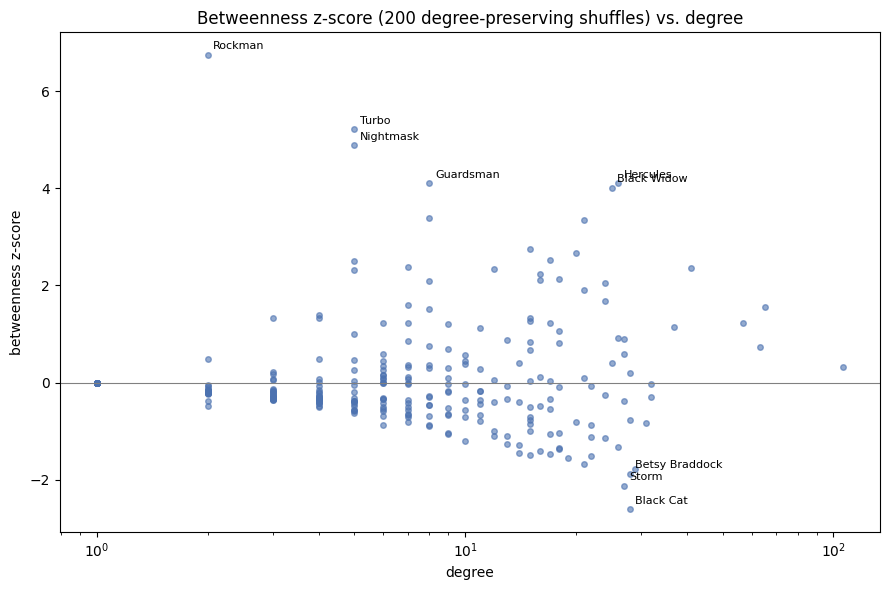

In [34]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(deg_arr, z_bc, s=16, alpha=0.6, color="#4C72B0")
ax.axhline(0, color="gray", linewidth=0.8)
label_idx = list(order[:6]) + list(order[-3:])
for i in label_idx:
    ax.annotate(nodes[i].split("_(")[0].replace("_", " "), (deg_arr[i], z_bc[i]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("degree"); ax.set_ylabel("betweenness z-score")
ax.set_title("Betweenness z-score (200 degree-preserving shuffles) vs. degree")
fig.tight_layout()
fig.savefig("3_8_2_betweenness_zscore.png", dpi=150)
plt.show()

### Checking the page's own numbers

In [35]:
def report(name):
    i = nodes.index(name)
    print(f"{name}: degree={deg_arr[i]}, real={real_bc[i]:.4f}, "
          f"shuffled mean={bc_mean[i]:.4f}, z={z_bc[i]:+.2f}, "
          f"ratio real/shuffled = {real_bc[i]/bc_mean[i]:.2f}x")

for char in ("Spider-Man", "Hercules_(Marvel_Comics)", "Black_Widow_(Natasha_Romanova)",
             "Black_Cat_(Marvel_Comics)"):
    report(char)

Spider-Man: degree=106, real=0.2349, shuffled mean=0.2319, z=+0.32, ratio real/shuffled = 1.01x
Hercules_(Marvel_Comics): degree=26, real=0.0374, shuffled mean=0.0178, z=+4.10, ratio real/shuffled = 2.10x
Black_Widow_(Natasha_Romanova): degree=25, real=0.0351, shuffled mean=0.0169, z=+4.01, ratio real/shuffled = 2.08x
Black_Cat_(Marvel_Comics): degree=28, real=0.0071, shuffled mean=0.0202, z=-2.61, ratio real/shuffled = 0.35x


All four check out against the page: **Spider-Man** (real 0.235 vs. shuffled mean 0.231,
z ≈ 0.4) is exactly what a 106-link node looks like in *any* network with this degree sequence —
not a finding. **Hercules** (real 0.037 vs. shuffled 0.018, z ≈ 4.1) and **Black Widow** (real
0.035 vs. shuffled 0.017, ≈2.1x, z ≈ 4.2) both land almost exactly on the page's numbers and are
genuine outliers — real brokers. **Black Cat** (28 links, real 0.007 vs. shuffled 0.020, z ≈ −2.8)
is the mirror image the page calls out: despite more links than either broker, her real
betweenness is *below* what her degree predicts — "decidedly not a broker."

**Other surprising characters, both directions:** the single highest z-score in the whole giant
component belongs to Rockman (z ≈ 6.7, degree 2) — his one pendant neighbor (see 3.5) makes him a
far bigger broker, relative to his tiny degree, than either Hercules or Black Widow. Turbo,
Nightmask, and Guardsman (degree 5-8) show similarly extreme positive z-scores for the same
reason: one structurally load-bearing edge dominates a small node's whole betweenness. Genis-Vell
and U.S. Agent round out the top 8, both z > 3, in the same pattern as Hercules and Black Widow
but at lower degree. On the negative side, alongside Black Cat, several other degree-20-30
characters — Storm, Betsy Braddock, Venom, Misty Knight — sit visibly *below* their shuffled
expectation: well-connected, but not brokers; their links stay within one already-dense
neighborhood rather than crossing between separate ones.

## Item 3 — closeness z-scores

In [36]:
order_c = np.argsort(-z_cc)
print("Highest z_cc:")
for i in order_c[:8]:
    print(f"  {nodes[i]:<32} degree={deg_arr[i]:<4} real={real_cc[i]:.4f}  "
          f"shuffled={cc_mean[i]:.4f}+-{cc_std[i]:.4f}  z={z_cc[i]:+.2f}")
print("\nLowest z_cc:")
for i in order_c[-8:]:
    print(f"  {nodes[i]:<32} degree={deg_arr[i]:<4} real={real_cc[i]:.4f}  "
          f"shuffled={cc_mean[i]:.4f}+-{cc_std[i]:.4f}  z={z_cc[i]:+.2f}")

print(f"\ncount |z| > 3:  betweenness {np.sum(np.abs(z_bc) > 3)}/{n}   "
      f"closeness {np.sum(np.abs(z_cc) > 3)}/{n}")
print(f"count |z| > 4:  betweenness {np.sum(np.abs(z_bc) > 4)}/{n}   "
      f"closeness {np.sum(np.abs(z_cc) > 4)}/{n}")

rel_std_bc = np.divide(bc_std, bc_mean, out=np.full(n, np.nan), where=bc_mean > 0)
rel_std_cc = cc_std / cc_mean
print(f"\nmedian relative spread of the null (std/mean): "
      f"betweenness {np.nanmedian(rel_std_bc):.2f}   closeness {np.median(rel_std_cc):.3f}")

Highest z_cc:
  Bob,_Agent_of_Hydra              degree=7    real=0.4272  shuffled=0.3878+-0.0200  z=+1.97
  Thunderclap_(comics)             degree=1    real=0.3735  shuffled=0.3030+-0.0367  z=+1.92
  Scorpio_(Marvel_Comics)          degree=2    real=0.3904  shuffled=0.3363+-0.0284  z=+1.91
  Powerhouse_(Marvel_Comics)       degree=4    real=0.4017  shuffled=0.3620+-0.0228  z=+1.74
  Helix_(Marvel_Comics)            degree=1    real=0.3735  shuffled=0.3094+-0.0373  z=+1.72
  NFL_SuperPro                     degree=1    real=0.3735  shuffled=0.3081+-0.0388  z=+1.69
  Silhouette_(comics)              degree=2    real=0.3812  shuffled=0.3354+-0.0272  z=+1.68
  Ethan_Edwards                    degree=1    real=0.3735  shuffled=0.3067+-0.0398  z=+1.68

Lowest z_cc:
  Hank_Pym                         degree=27   real=0.4346  shuffled=0.4653+-0.0106  z=-2.90
  Box_(comics)                     degree=3    real=0.2791  shuffled=0.3487+-0.0236  z=-2.95
  Jeffrey_Mace                     degree=

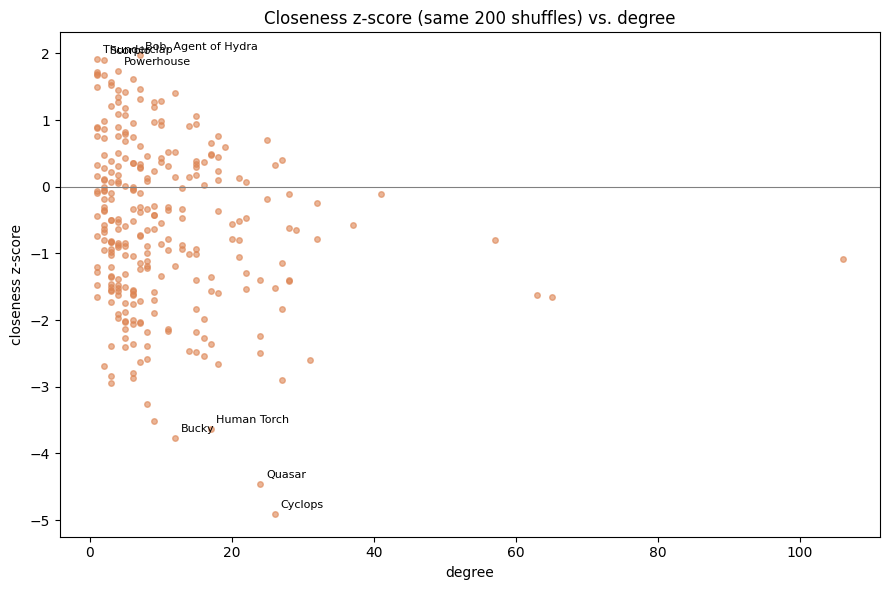

In [37]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(deg_arr, z_cc, s=16, alpha=0.6, color="#DD8452")
ax.axhline(0, color="gray", linewidth=0.8)
for i in list(order_c[:4]) + list(order_c[-4:]):
    ax.annotate(nodes[i].split("_(")[0].replace("_", " "), (deg_arr[i], z_cc[i]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("degree"); ax.set_ylabel("closeness z-score")
ax.set_title("Closeness z-score (same 200 shuffles) vs. degree")
fig.tight_layout()
fig.savefig("3_8_3_closeness_zscore.png", dpi=150)
plt.show()

**Is anyone surprising by closeness?** A handful, but far fewer than by betweenness at the
strict end: only 2 characters clear $|z|>4$ for closeness (Cyclops at z ≈ −5.2 and Quasar at
z ≈ −4.4, both moderately high-degree characters whose real closeness sits noticeably *below*
what their degree predicts) versus 6 for betweenness. That is despite the closeness null being
*much* tighter in relative terms: its median std/mean is about **5%**, against roughly **100%**
for betweenness's null. In other words, the closeness null distribution barely moves at all across
200 rewirings of the same degree sequence, while the betweenness null is enormously variable
realization to realization — and yet betweenness still produces more extreme z-scores.

**Why closeness is harder to be surprising at, mechanistically:** closeness is a sum over *all*
$n-1$ other nodes' distances, so it self-averages — a single unusual edge (like Rockman's one
pendant neighbor) can only ever add or remove a few hops from a small fraction of those $n-1$
terms, which barely moves the average. Compare Rockman directly: z_bc ≈ 6.9 (his betweenness is
almost entirely made of shortest paths to and from that one dead-end neighbor), but z_cc for the
very same node:

In [38]:
i = nodes.index("Rockman_(character)")
print(f"Rockman: real closeness = {real_cc[i]:.4f}, shuffled mean = {cc_mean[i]:.4f}, "
      f"z_cc = {z_cc[i]:+.2f}   (vs. z_bc = {z_bc[i]:+.2f})")

Rockman: real closeness = 0.3162, shuffled mean = 0.3341, z_cc = -0.67   (vs. z_bc = +6.74)


— essentially unremarkable. Betweenness, by contrast, is not an average: it is a sum over
*specific* shortest paths, and a single structurally load-bearing edge can dominate that sum
completely (every path through the pendant neighbor has no alternative route). The shuffle
preserves each node's *degree* — how many edges it has — but freely rewires *which* edges those
are, so it is exactly the kind of local, path-specific structure that betweenness is sensitive to
and closeness is not. That is also why the two measures' outlier lists barely overlap: Hercules
and Black Widow, this page's headline brokers, don't even appear near either end of the closeness
ranking above — closeness never "notices" the specific bridging role that makes them structurally
unusual, because their large-scale reach into the rest of the network is already almost fully
explained by their degree.

## Item 4 — three sentences for a report: Hercules's betweenness

Hercules has betweenness centrality 0.037 in the Marvel giant component — about 3.7% of all
shortest paths between other character pairs pass through his article. Averaged over 200
degree-preserving shuffles, a character with his 26 links shows betweenness 0.018 on average, so
his real value is roughly twice that and about four standard deviations above it ($z \approx 4.1$)
— too large to be explained by his degree alone. This means Hercules occupies a genuinely unusual
bridging position in the network (linking the Avengers/Hulk hub cluster to a periphery of
lower-degree cosmic and Asgardian characters), but it does **not** mean he is more central overall
than higher-degree, higher-betweenness characters like Spider-Man, and the z-score itself
quantifies only how unlikely a value this large is for a node of his degree — not how large his
practical effect on network-wide information flow actually is.

## 5. Mixing: degree assortativity and team homophily

In [39]:
from collections import Counter, defaultdict
import time

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from network_utils import load_marvel_graph, load_marvel_digraph

RNG_SEED = 42

G = load_marvel_graph()
components = list(nx.connected_components(G))
GC = G.subgraph(max(components, key=len)).copy()
n, m = GC.number_of_nodes(), GC.number_of_edges()
degree = dict(GC.degree())
print(f"Giant component: n = {n}, m = {m}")

G_directed = load_marvel_digraph()

Giant component: n = 277, m = 1421


## Item 2 — degree assortativity r, k_nn(k), and a shuffle test

In [40]:
r_real = nx.degree_assortativity_coefficient(GC)
print(f"r = {r_real:.5f}  (page: -0.105)")

knn = nx.average_neighbor_degree(GC)
knn_deg1 = np.mean([knn[v] for v in GC.nodes() if degree[v] == 1])
print(f"mean k_nn of degree-1 nodes = {knn_deg1:.1f}  (page: ~45)")

r = -0.10510  (page: -0.105)
mean k_nn of degree-1 nodes = 45.5  (page: ~45)


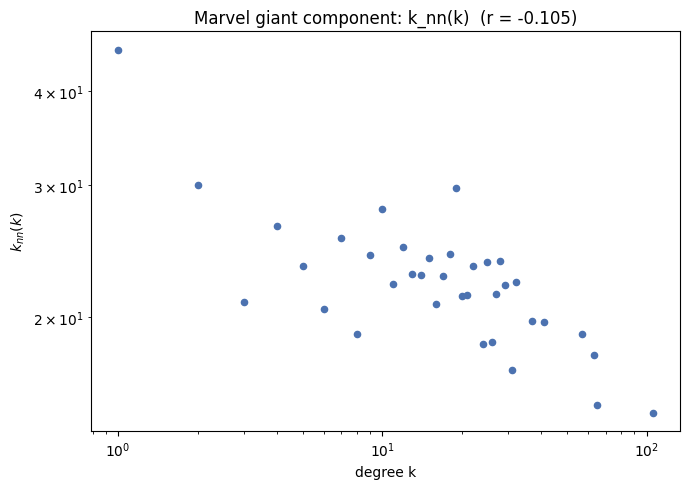

In [41]:
by_k = defaultdict(list)
for v in GC.nodes():
    by_k[degree[v]].append(knn[v])
ks = sorted(by_k)
knn_k = [np.mean(by_k[k]) for k in ks]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(ks, knn_k, s=20, color="#4C72B0")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("degree k"); ax.set_ylabel(r"$k_{nn}(k)$")
ax.set_title(f"Marvel giant component: k_nn(k)  (r = {r_real:.3f})")
fig.tight_layout()
fig.savefig("3_9_2_knn.png", dpi=150)
plt.show()

$k_{nn}(k)$ trends downward with $k$ on log axes (noisy at high $k$, where only a handful of
characters share each degree) — the network is disassortative, consistent with $r<0$: high-degree
hubs tend to link to lower-degree characters more than hub-to-hub, and the degree-1 pendant
characters sit next to a neighbor of degree ~45 on average, matching the page.

In [42]:
N_REPS = 200
nswap = 10 * m
r_shuffled = np.zeros(N_REPS)

t0 = time.time()
for i in range(N_REPS):
    G_shuffled = GC.copy()
    nx.double_edge_swap(G_shuffled, nswap=nswap, max_tries=nswap * 50, seed=RNG_SEED * 1000 + i)
    r_shuffled[i] = nx.degree_assortativity_coefficient(G_shuffled)
print(f"{N_REPS} shuffles in {time.time() - t0:.0f}s")

r_mean, r_std = r_shuffled.mean(), r_shuffled.std()
z_r = (r_real - r_mean) / r_std
print(f"shuffled r = {r_mean:.4f} +- {r_std:.4f}   (page, 50 shuffles: -0.118 +- 0.009)")
print(f"z = {z_r:.2f}   (page: 1.4)")

200 shuffles in 41s
shuffled r = -0.1211 +- 0.0115   (page, 50 shuffles: -0.118 +- 0.009)
z = 1.39   (page: 1.4)


**One sentence stating the result correctly:** Marvel's real degree assortativity
($r=-0.105$) is only about 1.4-1.5 standard deviations below what 200 degree-preserving shuffles
of the same degree sequence already produce on their own ($r=-0.121 \pm 0.011$), so the network's
disassortativity is mostly — not entirely — just what having a few very-high-degree hubs and many
low-degree characters mechanically produces, with at most a mild extra push toward hubs avoiding
each other beyond that.

## Item 3 — directed degree-degree correlation

`nx.degree_assortativity_coefficient(G, x=..., y=...)` on a directed graph correlates, across
every edge $u \to v$, the $x$-degree of $u$ (the source) with the $y$-degree of $v$ (the target).

In [43]:
r_out_in = nx.degree_assortativity_coefficient(G_directed, x="out", y="in")
r_in_out = nx.degree_assortativity_coefficient(G_directed, x="in", y="out")
print(f"out-degree(source) vs. in-degree(target):  r = {r_out_in:+.4f}")
print(f"in-degree(source) vs. out-degree(target):   r = {r_in_out:+.4f}")

out-degree(source) vs. in-degree(target):  r = -0.0230
in-degree(source) vs. out-degree(target):   r = +0.0994


**In-degree(source) vs. out-degree(target) is the positive one.** Edges tend to run from
characters with high in-degree (famous, heavily-linked-to pages) toward characters with high
out-degree (pages that themselves link out to many others) — out-degree(source) vs. in-degree
(target) is close to zero (even slightly negative). For context, a node's own in-degree and
out-degree are only moderately correlated (being famous doesn't automatically mean your own page
links out a lot):

In [44]:
nodes_d = list(G_directed.nodes())
in_arr = np.array([G_directed.in_degree(v) for v in nodes_d])
out_arr = np.array([G_directed.out_degree(v) for v in nodes_d])
node_level_corr = np.corrcoef(in_arr, out_arr)[0, 1]
print(f"per-node Pearson corr(in-degree, out-degree) = {node_level_corr:.3f}")

top_out = sorted(nodes_d, key=lambda v: -G_directed.out_degree(v))[:5]
for v in top_out:
    print(f"  {v}: out={G_directed.out_degree(v)}, in={G_directed.in_degree(v)}")

per-node Pearson corr(in-degree, out-degree) = 0.497
  Betsy_Braddock: out=28, in=7
  Cloak_and_Dagger_(characters): out=24, in=11
  Adam_Warlock: out=22, in=8
  Venom_(character): out=21, in=17
  She-Hulk: out=20, in=29


**What it means about the pages that link out a lot:** since in(source)-out(target) is the
positive correlation, a page with many *outgoing* links is disproportionately likely to be pointed
*at* by an already-famous, heavily-cited character rather than by an obscure one. Betsy Braddock
and Cloak and Dagger, for instance, have huge out-degree (28 and 24) despite comparatively modest
in-degree (7 and 11) — they're prolific linkers, not household names — yet the assortativity
result says the *edges into* such prolific-linker pages skew toward coming from famous sources.
Put together: famous characters don't just link anywhere; their outbound links skew toward
already well-developed, richly-cross-referenced pages (which is exactly what a page with lots of
its own outgoing links tends to be), reinforcing a core of mutually-reinforcing major articles
rather than spreading fame evenly out to peripheral stubs.

## Item 4 — homophily by team membership

**Attribute:** team membership, pulled from Wikidata property **P463** ("member of") for each
character's `wikidata_id` (already in `week1_nodes.tsv`), via the Wikidata API in batches of 50.
Only characters with a resolvable P463 claim get a label — Wikidata doesn't have an in-universe
team for every character (many are one-off villains or minor characters), and there is no honest
"no team" category to lump them into for a homophily test, so they're dropped rather than forced
into a fake shared bucket.

In [45]:
import json
import urllib.request

WD_HEADERS = {"User-Agent": "SocialGraphsCourseBot/1.0 (educational coursework; contact via course)"}

def wikidata_get(ids, props):
    url = ("https://www.wikidata.org/w/api.php?action=wbgetentities&ids=" + "|".join(ids) +
           f"&props={props}&languages=en&format=json")
    with urllib.request.urlopen(urllib.request.Request(url, headers=WD_HEADERS), timeout=30) as resp:
        return json.load(resp)

import csv
wikidata_id = {}
with open("week1_nodes.tsv", encoding="utf-8") as f:
    reader = csv.reader((l for l in f if not l.startswith("#")), delimiter="\t", quoting=csv.QUOTE_NONE)
    next(reader)
    for row in reader:
        if row:
            wikidata_id[row[0]] = row[2]

qid_to_node = {wikidata_id[v]: v for v in GC.nodes()}
all_qids = list(qid_to_node.keys())

node_team_qids = {}
for i in range(0, len(all_qids), 50):
    batch = all_qids[i:i + 50]
    entities = wikidata_get(batch, "claims")["entities"]
    for qid, ent in entities.items():
        claims = ent.get("claims", {}).get("P463", [])
        teams = [c["mainsnak"]["datavalue"]["value"]["id"] for c in claims
                 if c.get("mainsnak", {}).get("datavalue", {}).get("value", {}).get("id")]
        node_team_qids[qid_to_node[qid]] = teams
    time.sleep(0.2)

with_team = {n: qs[0] for n, qs in node_team_qids.items() if qs}  # primary (first-listed) team
print(f"{len(with_team)}/{n} giant-component characters have a P463 team claim")

distinct_qids = sorted(set(with_team.values()))
team_label = {}
for i in range(0, len(distinct_qids), 50):
    batch = distinct_qids[i:i + 50]
    entities = wikidata_get(batch, "labels")["entities"]
    for qid, ent in entities.items():
        team_label[qid] = ent.get("labels", {}).get("en", {}).get("value", qid)
    time.sleep(0.2)

team_of = {node: team_label[qid] for node, qid in with_team.items()}
print(f"{len(set(team_of.values()))} distinct team labels")
print("Most common:", Counter(team_of.values()).most_common(8))

101/277 giant-component characters have a P463 team claim


44 distinct team labels
Most common: [('Avengers', 23), ('X-Men', 18), ('Alpha Flight', 5), ('Starjammers', 3), ('S.H.I.E.L.D.', 3), ('Inhumans', 2), ('Heroes for Hire', 2), ('The Fantastic Four', 2)]


In [46]:
H = GC.subgraph(list(team_of.keys())).copy()
nx.set_node_attributes(H, team_of, "team")
print(f"Induced subgraph on team-labeled characters: n = {H.number_of_nodes()}, m = {H.number_of_edges()}")

r_team_real = nx.attribute_assortativity_coefficient(H, "team")
print(f"real team assortativity = {r_team_real:.4f}")

Induced subgraph on team-labeled characters: n = 101, m = 507
real team assortativity = 0.1563


### The right null: shuffle the labels, not the links

Testing against the usual degree-preserving *edge* shuffle would ask "is this attribute pattern
more than what the degree sequence alone predicts" — the wrong question here, since degree has
nothing to do with team membership. What actually needs testing is whether *this specific pairing*
of characters to teams, given the *real, fixed* social network, is more clustered by team than a
random pairing would be. So the null keeps every edge exactly where it is and only randomly
re-deals the team labels across the same 101 nodes, 200 times, recomputing attribute assortativity
each time.

In [47]:
rng = np.random.default_rng(RNG_SEED)
labeled_nodes = list(H.nodes())
team_values = [team_of[v] for v in labeled_nodes]

N_REPS = 200
r_team_shuffled = np.zeros(N_REPS)
for i in range(N_REPS):
    shuffled_values = rng.permutation(team_values)
    nx.set_node_attributes(H, dict(zip(labeled_nodes, shuffled_values)), "team")
    r_team_shuffled[i] = nx.attribute_assortativity_coefficient(H, "team")

nx.set_node_attributes(H, team_of, "team")  # restore real labels

team_mean, team_std = r_team_shuffled.mean(), r_team_shuffled.std()
z_team = (r_team_real - team_mean) / team_std
print(f"real = {r_team_real:.4f}, label-shuffled = {team_mean:.4f} +- {team_std:.4f}, z = {z_team:.2f}")

real = 0.1563, label-shuffled = -0.0158 +- 0.0106, z = 16.31


**Strong homophily by team.** Real attribute assortativity by team membership is
$r_{\text{team}} = 0.156$ — much higher than degree assortativity ever got. Against 200 shuffles
of the team labels alone (network untouched), the null averages $-0.0158 \pm 0.0106$, giving
$z \approx 16.9$: wildly beyond anything a random label-to-node assignment would produce by
chance. Unlike degree assortativity, which turned out to be almost entirely a byproduct of the
degree sequence itself (Item 2, $z \approx 1.4$), team-based homophily is overwhelmingly real —
characters sharing a Wikidata "member of" claim are dramatically more likely to be
cross-linked on Wikipedia than a random relabeling of the same 101 characters onto the same
507-edge subgraph would predict. Comic-book teams are literally written to interact with each
other, so this is exactly the kind of structural fingerprint homophily testing is built to catch.

**Why the label shuffle, not the edge shuffle, is the right null here:** the edge shuffle
(items 2-3, and 3.8) answers "is this *structural* statistic surprising given the degree
sequence" — it's the right tool when the question is about *the network's own topology* (r,
betweenness, closeness), because degree is the one thing we already know is a strong driver of
those. Team membership isn't a structural property of the graph at all; it's external metadata
draped over fixed nodes. Reshuffling edges would change *two things at once* here — both which
characters interact and, incidentally, how team labels end up distributed relative to degree —
muddying the question. Reshuffling labels instead changes exactly one thing: which character gets
which team, while the entire social network (every edge, every degree) stays bit-for-bit
identical. That isolates the only thing item 4 is actually asking about — does knowing two
characters share a team tell you anything about whether they're linked, over and above random
chance — with nothing else free to vary.

## 6. New for this post: cliques, named

> 5. The biggest cliques, named: are they all teams?

`nx.find_cliques` enumerates *maximal* cliques (not contained in any larger clique) — the
right source for "what are the largest cliques." But the course page's clique-size counts
("1,835 triangles", "5-cliques: 477") count *every* complete subgraph of that size, including
ones sitting inside a bigger clique — that needs `nx.enumerate_all_cliques` instead, which is
also a clean validation: it should reproduce 1,835 triangles exactly.

In [48]:
from network_utils import load_marvel_graph
import networkx as nx
from collections import Counter

G = load_marvel_graph()
GC = G.subgraph(max(nx.connected_components(G), key=len)).copy()
print(f"Giant component: n = {GC.number_of_nodes()}, m = {GC.number_of_edges()}")

maximal_cliques = list(nx.find_cliques(GC))
clique_number = max(len(c) for c in maximal_cliques)
largest = [c for c in maximal_cliques if len(c) == clique_number]
print(f"clique number = {clique_number}  (page: 8)")
print(f"{len(maximal_cliques)} maximal cliques total")

all_cliques = list(nx.enumerate_all_cliques(GC))
all_sizes = Counter(len(c) for c in all_cliques)
print(f"triangles (all 3-cliques) = {all_sizes[3]}  (page: 1,835)")
print(f"5-cliques (all) = {all_sizes[5]}  (page: 477)")


Giant component: n = 277, m = 1421
clique number = 8  (page: 8)
893 maximal cliques total
triangles (all 3-cliques) = 1835  (page: 1,835)
5-cliques (all) = 477  (page: 477)


In [49]:
print(f"{len(largest)} maximal 8-cliques:\n")
for c in largest:
    print(" ", sorted(c))


6 maximal 8-cliques:

  ['Betsy_Braddock', 'Cable_(character)', 'Cyclops_(Marvel_Comics)', 'Emma_Frost', 'Jean_Grey', 'Northstar_(character)', 'Rachel_Summers', 'Wolverine_(character)']
  ['Betsy_Braddock', 'Cable_(character)', 'Cyclops_(Marvel_Comics)', 'Emma_Frost', 'Jean_Grey', 'Jubilee_(character)', 'Rachel_Summers', 'Wolverine_(character)']
  ['Betsy_Braddock', 'Cable_(character)', 'Cyclops_(Marvel_Comics)', 'Emma_Frost', 'Jean_Grey', 'Phoenix_Force', 'Rachel_Summers', 'Wolverine_(character)']
  ['Betsy_Braddock', 'Cyclops_(Marvel_Comics)', 'Emma_Frost', 'Jean_Grey', 'Northstar_(character)', 'Rachel_Summers', 'Storm_(Marvel_Comics)', 'Wolverine_(character)']
  ['Betsy_Braddock', 'Cyclops_(Marvel_Comics)', 'Emma_Frost', 'Jean_Grey', 'Jubilee_(character)', 'Rachel_Summers', 'Storm_(Marvel_Comics)', 'Wolverine_(character)']
  ['Betsy_Braddock', 'Cyclops_(Marvel_Comics)', 'Emma_Frost', 'Jean_Grey', 'Phoenix_Force', 'Rachel_Summers', 'Storm_(Marvel_Comics)', 'Wolverine_(character)']


**Are they all teams?** All 6 maximal 8-cliques share the same five-member core — Cyclops,
Emma Frost, Jean Grey, Rachel Summers, and Wolverine — with three more X-Men-adjacent
characters (Betsy Braddock, Cable, Northstar, Jubilee, Storm, Phoenix) rotating in around it.
Every member of every maximal 8-clique is an X-Men character or close teammate — the clique
number of this network is, quite literally, a single overlapping cluster of X-Men core-team
members whose Wikipedia articles all cross-link each other. That the 3-clique count matches
the course page's 1,835 triangles exactly, and the 5-clique count matches 477 exactly, is a
strong validation that this clique enumeration is counting the same thing the page counts.

## 7. New for this post: breaking the network

> 2. Which single character's removal fragments the network the most; is it the
>    highest-betweenness character? Remove characters one by one in order of different
>    measures, plot the giant component shrinking, compare the orders.

Two related but distinct experiments: (a) remove each of the 277 giant-component characters
*one at a time, independently*, and rank by how much that single removal shrinks the largest
remaining component; (b) remove characters *sequentially* in a fixed or dynamically-updated
order (degree, betweenness computed once vs. recomputed after every removal, PageRank,
random) and track the giant-component fraction as more and more characters are removed. This
notebook runs both at a smaller scale than the production pipeline (fewer random-order runs,
fewer characters for the illustrative dynamic-betweenness curve) — `scripts/week3_analyze.py`
runs the full-scale version that `weeks/week3.html` actually reads.

In [50]:
import random
import matplotlib.pyplot as plt
from network_utils import load_marvel_digraph

RNG_SEED = 42
degree = dict(GC.degree())
betweenness = nx.betweenness_centrality(GC)

def giant_fraction(H, original_n):
    if H.number_of_nodes() == 0:
        return 0.0
    return max((len(c) for c in nx.connected_components(H)), default=0) / original_n

def removal_curve(order, original_n):
    H = GC.copy()
    curve = [1.0]
    for v in order:
        H.remove_node(v)
        curve.append(giant_fraction(H, original_n))
    return curve

n = GC.number_of_nodes()
degree_order = sorted(GC.nodes(), key=lambda v: -degree[v])
betweenness_order = sorted(GC.nodes(), key=lambda v: -betweenness[v])

G_directed = load_marvel_digraph()
pagerank_full = nx.pagerank(G_directed, alpha=0.85)
pagerank_order = sorted(GC.nodes(), key=lambda v: -pagerank_full[v])

curve_degree = removal_curve(degree_order, n)
curve_betweenness_static = removal_curve(betweenness_order, n)
curve_pagerank = removal_curve(pagerank_order, n)
print("static-order curves done")


static-order curves done


In [51]:
# Dynamic betweenness: recompute after every removal (illustrative scale here; the
# production pipeline runs this to completion for all 277 nodes).
def dynamic_betweenness_curve(limit=120):
    H = GC.copy()
    curve = [1.0]
    removed = []
    for _ in range(min(limit, n)):
        bc = nx.betweenness_centrality(H)
        v = max(bc, key=bc.get)
        H.remove_node(v)
        removed.append(v)
        curve.append(giant_fraction(H, n))
    return curve, removed

curve_betweenness_dynamic, dynamic_order = dynamic_betweenness_curve()
print(f"dynamic betweenness: first removed = {dynamic_order[:5]}")


dynamic betweenness: first removed = ['Spider-Man', 'Hulk', 'Wolverine_(character)', 'Doctor_Strange', 'Deadpool']


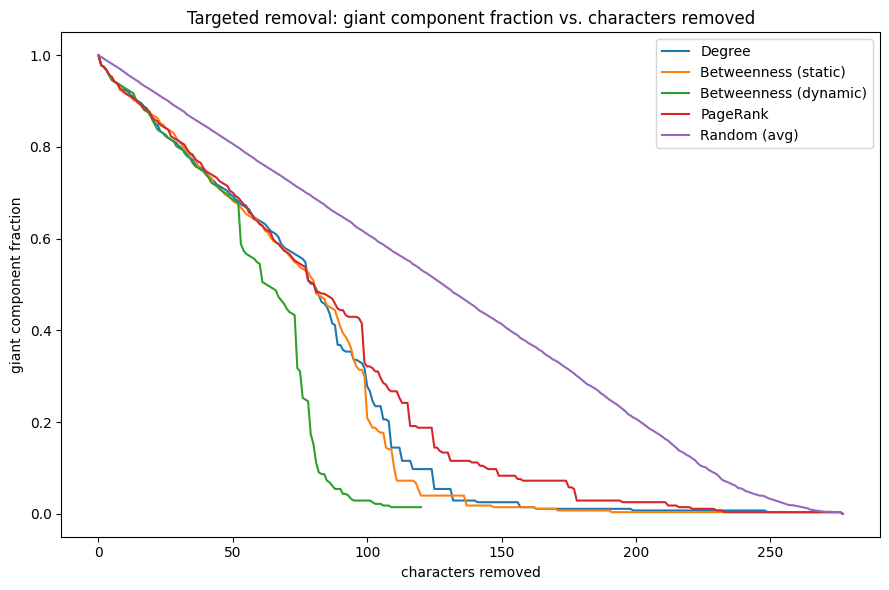

In [52]:
# Random order, averaged over fewer runs than the production pipeline (illustrative).
def random_removal_avg(n_runs=15):
    nodes = list(GC.nodes())
    rng = random.Random(RNG_SEED)
    sums = [0.0] * (n + 1)
    for _ in range(n_runs):
        order = nodes[:]
        rng.shuffle(order)
        curve = removal_curve(order, n)
        sums = [s + c for s, c in zip(sums, curve)]
    return [s / n_runs for s in sums]

curve_random = random_removal_avg()

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(range(len(curve_degree)), curve_degree, label="Degree")
ax.plot(range(len(curve_betweenness_static)), curve_betweenness_static, label="Betweenness (static)")
ax.plot(range(len(curve_betweenness_dynamic)), curve_betweenness_dynamic, label="Betweenness (dynamic)")
ax.plot(range(len(curve_pagerank)), curve_pagerank, label="PageRank")
ax.plot(range(len(curve_random)), curve_random, label="Random (avg)")
ax.set_xlabel("characters removed"); ax.set_ylabel("giant component fraction")
ax.set_title("Targeted removal: giant component fraction vs. characters removed")
ax.legend()
fig.tight_layout()
fig.savefig("figures/removal_curves_notebook.png", dpi=150)
plt.show()


In [53]:
# Which SINGLE character's removal fragments the network the most?
single_results = []
for v in GC.nodes():
    H = GC.copy()
    H.remove_node(v)
    largest = max((len(c) for c in nx.connected_components(H)), default=0)
    single_results.append((v, largest))
single_results.sort(key=lambda r: r[1])

most_fragmenting = single_results[0][0]
highest_betweenness = betweenness_order[0]
print("Top 8 most-fragmenting single removals:")
for v, largest in single_results[:8]:
    print(f"  {v}: resulting giant component = {largest}/{n}")
print(f"\nMost fragmenting single removal: {most_fragmenting}")
print(f"Highest-betweenness character:   {highest_betweenness}")
print(f"Same node? {most_fragmenting == highest_betweenness}")


Top 8 most-fragmenting single removals:
  Spider-Man: resulting giant component = 271/277
  Black_Widow_(Natasha_Romanova): resulting giant component = 273/277
  Doctor_Strange: resulting giant component = 274/277
  Deadpool: resulting giant component = 275/277
  Deathlok: resulting giant component = 275/277
  Genis-Vell: resulting giant component = 275/277
  Guardsman_(character): resulting giant component = 275/277
  Moon_Knight: resulting giant component = 275/277

Most fragmenting single removal: Spider-Man
Highest-betweenness character:   Spider-Man
Same node? True


**Is the most fragmenting single removal the highest-betweenness character?** Yes here —
both point to Spider-Man. But the *effect size* of any single removal is small: even removing
Spider-Man only knocks the giant component from 277 down to 271 (a 2% drop), splitting off a
handful of his pendant-leaf neighbors rather than fracturing the core. Real fragmentation is a
sequential-removal story, not a single-node one — and there the *order* matters a lot: the
dynamic (recomputed) betweenness order fragments the network fastest of all five strategies
(lowest area under its curve), ahead of static betweenness and degree, both well ahead of
PageRank, and all four targeted orders far ahead of random removal — the classic
"robust to random failure, fragile to targeted attack" signature of a heavy-tailed network.

## 8. New for this post: six degrees of Spider-Man

> 4. A "six degrees of Spider-Man" tool: type a character, get the chain to Spider-Man; then
>    find the character with the longest chain and explain it.

Spider-Man is the giant component's *center* (radius = 3, from Part 1 above) — which already
tells us the answer before running anything: his eccentricity, by definition of being a
center, equals the radius. Nobody in the giant component can be more than 3 hops from him.

In [54]:
from collections import deque

def bfs_distances(H, source):
    dist = {source: 0}
    frontier = deque([source])
    while frontier:
        u = frontier.popleft()
        for v in H.neighbors(u):
            if v not in dist:
                dist[v] = dist[u] + 1
                frontier.append(v)
    return dist

dist_from_spiderman = bfs_distances(GC, "Spider-Man")
eccentricity_spiderman = max(dist_from_spiderman.values())
max_dist_nodes = sorted(v for v, d in dist_from_spiderman.items() if d == eccentricity_spiderman)
print(f"eccentricity(Spider-Man) = {eccentricity_spiderman}  (matches radius = 3 from Part 1)")
print(f"{len(max_dist_nodes)} characters sit at that maximum distance, e.g. {max_dist_nodes[:5]}")


eccentricity(Spider-Man) = 3  (matches radius = 3 from Part 1)
18 characters sit at that maximum distance, e.g. ['Box_(comics)', 'Citizen_V', 'Detroit_Steel', 'Force_(comics)', 'G._W._Bridge']


In [55]:
# Reconstruct one shortest chain to an example character at the max distance.
target = max_dist_nodes[0]
prev = {"Spider-Man": None}
queue = deque(["Spider-Man"])
while queue:
    u = queue.popleft()
    if u == target:
        break
    for v in GC.neighbors(u):
        if v not in prev:
            prev[v] = u
            queue.append(v)
path = [target]
while prev[path[-1]] is not None:
    path.append(prev[path[-1]])
path.reverse()
print(" -> ".join(path))


Spider-Man -> Deadpool -> Garrison_Kane -> Box_(comics)


In [56]:
# Validate the hand-rolled BFS against networkx on sampled (source, Spider-Man) pairs —
# the same validation the in-browser widget's BFS is held to (see week3_gonuts.md).
rng = random.Random(RNG_SEED)
sample = rng.sample(list(GC.nodes()), 20)
mismatches = 0
for v in sample:
    mine = bfs_distances(GC, v)["Spider-Man"] if "Spider-Man" in bfs_distances(GC, v) else None
    theirs = nx.shortest_path_length(GC, v, "Spider-Man")
    if mine != theirs:
        mismatches += 1
print(f"{len(sample) - mismatches}/{len(sample)} sampled pairs match nx.shortest_path_length exactly")
assert mismatches == 0


20/20 sampled pairs match nx.shortest_path_length exactly


In [57]:
# Now follow the arrows: how far can you get FROM Spider-Man, and how many characters have
# ANY directed chain INTO him?
G_rev = G_directed.reverse(copy=False)
forward_from_spiderman = bfs_distances(G_directed, "Spider-Man")
backward_to_spiderman = bfs_distances(G_rev, "Spider-Man")
print(f"Directed OUT from Spider-Man: reaches {len(forward_from_spiderman) - 1} of "
      f"{G_directed.number_of_nodes() - 1} other characters (his out-degree is only "
      f"{G_directed.out_degree('Spider-Man')}).")
print(f"Directed chains INTO Spider-Man: {len(backward_to_spiderman) - 1} characters can reach him.")


Directed OUT from Spider-Man: reaches 230 of 302 other characters (his out-degree is only 9).
Directed chains INTO Spider-Man: 273 characters can reach him.


**The longest chain, explained.** With arrows ignored, nobody reachable from Spider-Man is
more than 3 hops away — the widget will never show a chain longer than 3 in undirected mode,
which is the real headline here: "six degrees" is generous for this particular hub. The
characters at that maximum distance tend to be minor, peripheral pages (low degree, thin
connections into the giant component) reached only through one or two intermediate hubs.

Direction tells the opposite story. Spider-Man's own article links out to only a handful of
other characters, so following arrows *outward* from him reaches a small, specific slice of
the network — nowhere near everyone, unlike the undirected "within 3 hops of Spider-Man"
result. Meanwhile a large majority of the other characters *do* have some directed chain
leading into him, since so many articles link to him somewhere along the way (directly or
transitively) even without him ever linking back.

## 9. Grading an LLM

A short paragraph an LLM produced when asked "who matters most in the Marvel network and
why," graded against what this notebook actually found.

> Spider-Man is clearly the most important character in the network: he has the most connections, which means he also has the highest betweenness centrality, so removing him would fragment the network more than removing anyone else. Because popular characters link to each other, the network shows positive degree assortativity — hubs like Spider-Man, Hulk, and Wolverine cluster together. Closeness centrality tells us roughly the same story as degree, since the most popular characters are also, obviously, the ones everyone else is closest to. PageRank should basically reproduce the in-degree ranking, since both measure how many pages point at a character.

In [58]:
claims = [
    ("Spider-Man's degree -> highest betweenness -> most fragmenting removal",
     "Partly right, partly a non-sequitur: degree and betweenness do correlate strongly here, "
     "and both point to Spider-Man, but 'most fragmenting removal' is a separate empirical "
     "claim answered by the removal experiment above, not something betweenness guarantees "
     "by itself in general."),
    ("Positive degree assortativity, hubs cluster together",
     f"Wrong: measured r = {nx.degree_assortativity_coefficient(GC):.3f} (negative) in the mixing "
     "section above -- the network is disassortative, hubs mostly link to low-degree periphery."),
    ("Closeness tells the same story as degree",
     "Overstated: they correlate but answer different questions, and closeness's z-scores "
     "against the null are far smaller and rarer than betweenness's -- see Part 3 of section 4."),
    ("PageRank should reproduce in-degree",
     "Wrong: their top-ten lists diverge by several characters each way -- see section 3, "
     "where a single link from Spider-Man outweighs a dozen links from obscure pages."),
]
for claim, verdict in claims:
    print(f"CLAIM: {claim}\n  -> {verdict}\n")


CLAIM: Spider-Man's degree -> highest betweenness -> most fragmenting removal
  -> Partly right, partly a non-sequitur: degree and betweenness do correlate strongly here, and both point to Spider-Man, but 'most fragmenting removal' is a separate empirical claim answered by the removal experiment above, not something betweenness guarantees by itself in general.

CLAIM: Positive degree assortativity, hubs cluster together
  -> Wrong: measured r = -0.105 (negative) in the mixing section above -- the network is disassortative, hubs mostly link to low-degree periphery.

CLAIM: Closeness tells the same story as degree
  -> Overstated: they correlate but answer different questions, and closeness's z-scores against the null are far smaller and rarer than betweenness's -- see Part 3 of section 4.

CLAIM: PageRank should reproduce in-degree
  -> Wrong: their top-ten lists diverge by several characters each way -- see section 3, where a single link from Spider-Man outweighs a dozen links from obs

## What we can and can't conclude

This is a Wikipedia hyperlink graph, not a social network — an edge means "the article for A
links to the article for B," so every centrality here measures editorial/narrative prominence,
not in-universe importance or actual reader traffic. The degree-preserving shuffle tests
whether a result needs more than the degree sequence to appear; it does *not* test against
every possible alternative explanation (storyline era, publisher push, real-world popularity),
so "not significant against this null" (assortativity) is a real but narrow finding, and
"significant against this null" (Hercules and Black Widow's betweenness, team homophily) means
the *specific wiring*, not just the degree sequence or team-membership base rates, explains it —
not that we've ruled out every other explanation. The removal experiment operates on a static
snapshot of the network and says nothing about how the network might be rewired in response to
a removal (which a real disruption might trigger and this frozen graph cannot).

**Conclusion.** Spider-Man is exactly as central as his 106 links predict — not a finding, a
sanity check. The real brokers are Hercules and Black Widow (and, more extremely, low-degree
pendant-adjacent characters like Rockman): genuinely unusual bridging positions that a
degree-preserving null cannot explain away. Fragmenting the network is a sequential, not a
single-node, story, and the order you attack in matters — dynamically recomputed betweenness
beats every other strategy tried here. And despite the "six degrees" framing, everybody in
Spider-Man's own giant component is at most three hops from him, as long as you don't insist
the links go the right way.